# Smart Warehouse AI System


**Dataset:** UCI Online Retail Dataset (Dec 2010 -- Dec 2011)  
**Methodology:** Agile SDLC + NASA System Engineering Product Life Cycle  
**Language:** Python 3 -- pandas -- numpy -- scikit-learn -- matplotlib -- ipywidgets  
**Subsystems:**
* (1) Data Ingestion
* (2) Demand Forecasting/RF
* (3) Anomaly Detection/IsolationForest
* (4) Customer Segmentation/KMeans
* (5) Fuzzy Logic Reorder System

---
### How to use this notebook
1. Run **Cell 2** first to install dependencies
2. Run **Cell 3** to load the dataset *(pick 3A/3B/3C)*
3. Run cells top-to-bottom -- each section builds on the previous one
4. Use the **interactive widgets** at the bottom to explore forecasts and alerts

> **Tip:** Runtime -> Run all will execute every cell automatically.

## Cell 2 -- Install & Import Dependencies


In [ ]:
# Install packages not bundled with Colab
# scikit-learn, pandas, matplotlib, numpy are pre-installed
!pip install -q openpyxl==3.1.2 scikit-fuzzy networkx scipy

import warnings, os, io, json, math, urllib.request
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib; matplotlib.use('Agg') if 'google.colab' not in str(get_ipython()) else None
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.rcParams['figure.dpi'] = 150
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline
plt.style.use('dark_background')
COLORS = ['#00d4ff','#ff6b35','#7fff00','#ff1493','#ffd700','#da70d6','#87ceeb','#98fb98']
FBG='#0d1117'; ABG='#161b22'; TC='#e6edf3'; MC='#8b949e'

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from scipy.interpolate import RegularGridInterpolator
import skfuzzy as fuzz
from skfuzzy import control as ctrl

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_OK = True
except ImportError:
    WIDGETS_OK = False
    print('ipywidgets not available -- interactive sections will be skipped')

print('✅ All libraries loaded successfully!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
#print(f'   sklearn : __import__("sklearn").__version__')
import sklearn
print(f'   sklearn : {sklearn.__version__}')

✅ All libraries loaded successfully!
   pandas  : 2.2.2
   numpy   : 2.0.2
   sklearn : 1.6.1


## Cell 3 -- Load the Dataset

**Three options -- run whichever suits your setup:**

| Option | Method | Best for |
|--------|--------|----------|
| **3A** | Upload from computer | Quick, no Drive needed |
| **3B** | Mount Google Drive | If file is already in Drive |
| **3C** | Auto-download from UCI | Works without any file |

Run exactly ONE of 3A, 3B, or 3C -- then skip to Cell 4.

In [ ]:
# ============================================
#  Interactive Data Loader
#  Choose your method, then click "Load Data"
# ============================================
import os, io, urllib.request, warnings
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings('ignore')

# UI layout ----------------------------------------------------------------
method_radio = widgets.RadioButtons(
    options=[
        ('3A  --  Upload from my computer (recommended)',  '3A'),
        ('3B  --  Load from Google Drive',                 '3B'),
        ('3C  --  Auto-download from UCI repository',      '3C'),
    ],
    value='3A',
    layout=widgets.Layout(width='500px'),
)

drive_path_box = widgets.Text(
    value='/content/drive/MyDrive/Online Retail.xlsx',
    description='Drive path:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='500px', display='none'),
)

load_btn  = widgets.Button(description='Load Data',
                            button_style='primary',
                            icon='database',
                            layout=widgets.Layout(width='160px', height='36px'))

status_out = widgets.Output()

# Show / hide Drive path box depending on selection
def on_method_change(change):
    drive_path_box.layout.display = '' if change['new'] == '3B' else 'none'

method_radio.observe(on_method_change, names='value')

display(widgets.VBox([
    widgets.HTML("<h3 style='color:#00d4ff'>SmartWH -- Data Loading</h3>"),
    method_radio,
    drive_path_box,
    load_btn,
    status_out,
]))

# Button handler -----------------------------------------------------------
# XLSX_PATH = None
# df_raw = None

def on_load_clicked(b):
    global XLSX_PATH, df_raw
    with status_out:
        clear_output(wait=True)
        choice = method_radio.value

        # 3A: Upload from computer ─────────────────────────────────────────
        if choice == '3A':
            print('Opening file picker -- select your "Online Retail.xlsx" ...')
            from google.colab import files as colab_files
            uploaded = colab_files.upload()
            if not uploaded:
                print('[ERROR] No file uploaded. Please try again.')
                return
            fname    = next(iter(uploaded))
            raw_bytes = uploaded[fname]
            XLSX_PATH = f'/content/{fname}'
            with open(XLSX_PATH, 'wb') as f:
                f.write(raw_bytes)
            print(f'[OK] Saved uploaded file to {XLSX_PATH}')

        # 3B: Google Drive ─────────────────────────────────────────────────
        elif choice == '3B':
            XLSX_PATH = drive_path_box.value.strip()
            if not os.path.isfile(XLSX_PATH):
                print('Mounting Google Drive ...')
                from google.colab import drive
                drive.mount('/content/drive', force_remount=False)
            if not os.path.isfile(XLSX_PATH):
                print(f'[ERROR] File not found: {XLSX_PATH}')
                print('Check the path in the Drive path box above and try again.')
                return
            print(f'[OK] Found file on Drive: {XLSX_PATH}')

        # 3C: UCI download ─────────────────────────────────────────────────
        elif choice == '3C':
            XLSX_PATH = '/content/Online_Retail.xlsx'
            UCI_URL   = ('https://archive.ics.uci.edu/ml/machine-learning-databases'
                         '/00352/Online%20Retail.xlsx')
            if os.path.isfile(XLSX_PATH):
                print(f'[OK] Using cached file: {XLSX_PATH}')
            else:
                print('Downloading from UCI repository (this may take ~30 s) ...')
                try:
                    req = urllib.request.Request(
                        UCI_URL,
                        headers={'User-Agent': 'Mozilla/5.0 (WareIQ/1.0)'}
                    )
                    with urllib.request.urlopen(req, timeout=120) as resp:
                        data = resp.read()
                    with open(XLSX_PATH, 'wb') as f:
                        f.write(data)
                    print(f'[OK] Downloaded {len(data):,} bytes  ->  {XLSX_PATH}')
                except Exception as e:
                    print(f'[ERROR] Download failed: {e}')
                    print('Try option 3A (upload) or 3B (Drive) instead.')
                    return

        # Read into DataFrame (common to all options) ───────────────────────
        print(f'\nReading Excel file: {XLSX_PATH} ...')
        try:
            df_raw = pd.read_excel(
                XLSX_PATH,
                dtype={'InvoiceNo': str, 'StockCode': str},
            )
            print(f'[OK] Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
            print(f'     Columns: {list(df_raw.columns)}')
            display(df_raw.head(3))
            print('\n✅ Ready! Run Cell 4 to begin analysis.')
        except Exception as e:
            print(f'⚠️ [ERROR] Could not read file: {e}')

load_btn.on_click(on_load_clicked)

---
## Cell 4 -- Subsystem 1: Data Ingestion & Validation & Feature Engineering

**NASA Phase A (Concept & Technology Development)**

This subsystem cleans, validates and transforms the raw Online Retail data
into analysis-ready structures used by all downstream subsystems.

**Cleaning rules applied:**
- Remove cancelled invoices (prefix 'C') -- not real demand signals
- Remove Quantity <= 0 and UnitPrice <= 0 -- data entry errors or returns
- Impute missing Description from StockCode -- fill in missing Description based on StockCode
- Handle missing CustomerID -- fill in with 'ANON'

**Engineered features:** InvoiceDate, TotalRevenue, Year, Month, Week, Date, Quarter, DayOfWeek, IsWeekend


 [Subsystem 1] Data Ingestion & Validation & Feature Engineering
  Engineered 9 new features: InvoiceDate, TotalRevenue, Year, Month, Week, Date, Quarter, DayOfWeek, IsWeekend
  Cleaned: 541,909 -> 530,104 rows (removed 11,805)
  Segmentation stream: 397,884 rows (4,338 unique customers)
  Daily demand: 276,148 records
  Inventory: 3,922 SKUs
  Segmentation stream: 4,338 unique customers

Sample cleaned data:
  InvoiceNo StockCode                         Description  Quantity  UnitPrice  TotalRevenue
0    536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6       2.55         15.30
1    536365     71053                 WHITE METAL LANTERN         6       3.39         20.34
2    536365    84406B      CREAM CUPID HEARTS COAT HANGER         8       2.75         22.00



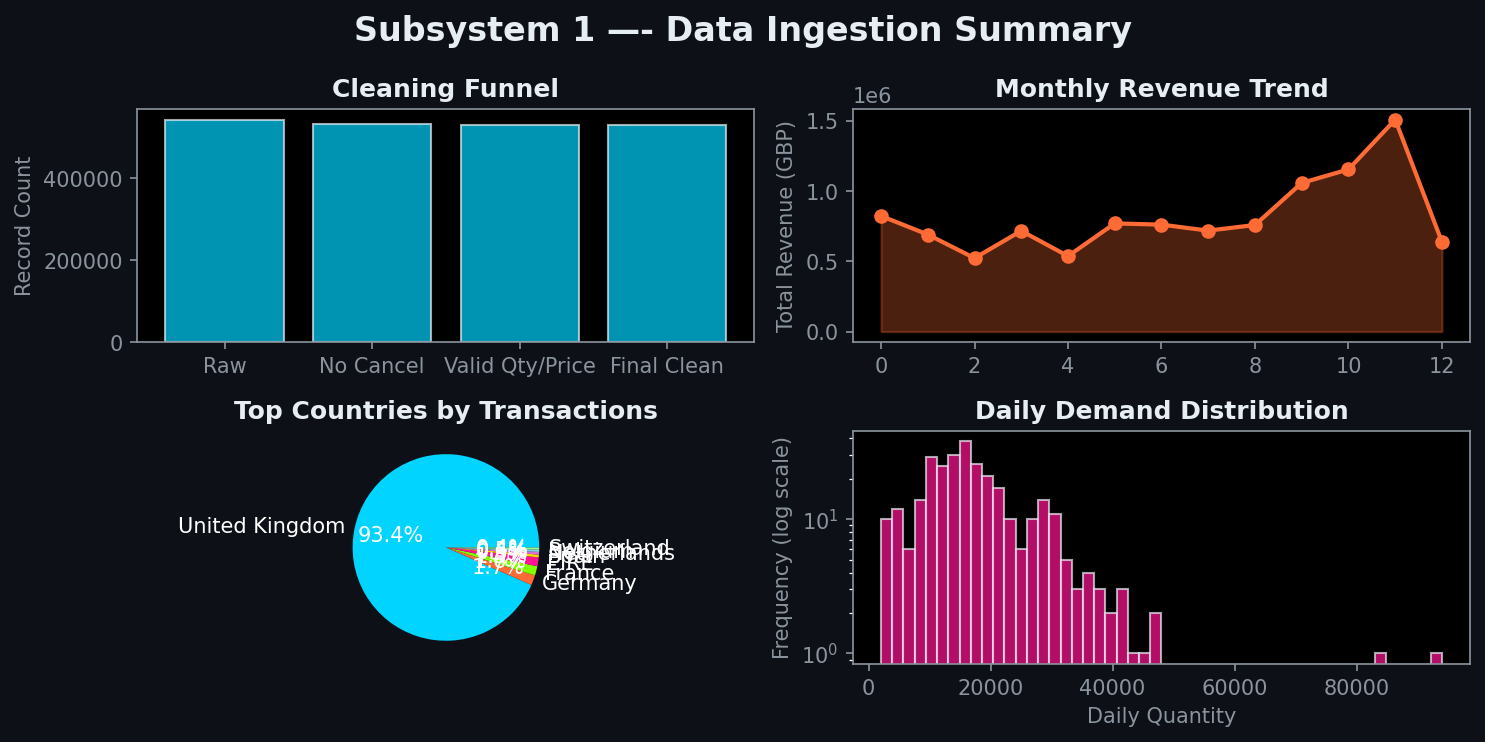


✅ Subsystem 1 -- Data Ingestion visualization complete.


In [ ]:
# ==================================================================
#  Subsystem 1 -- Data Ingestion & Validation & Feature Engineering
# ==================================================================

def validate_schema(df):
    required = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
    missing = [c for c in required if c not in df.columns]
    return len(missing) == 0, missing

def clean_data(df):
    # Drop cancelled invoices (prefix 'C')
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
    # Drop invalid Quantity and Price
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
    # Impute missing Description from StockCode mode
    if df['Description'].isna().any():
        mode_desc = df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'UNKNOWN')
        df['Description'] = df.apply(lambda r: mode_desc.get(r['StockCode'], 'UNKNOWN') if pd.isna(r['Description']) else r['Description'], axis=1)
    # Handle missing CustomerID
    df['HasCustomerID'] = ~df['CustomerID'].isna()
    df['CustomerID'] = df['CustomerID'].fillna('ANON')
    return df

def engineer_features(df):
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
    df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
    df['Year']       = df['InvoiceDate'].dt.year
    df['Month']      = df['InvoiceDate'].dt.month
    df['Week']       = df['InvoiceDate'].dt.isocalendar().week.astype(int)
    df['Date']       = df['InvoiceDate'].dt.date
    df['Quarter']    = df['InvoiceDate'].dt.quarter
    df['DayOfWeek']  = df['InvoiceDate'].dt.dayofweek
    df['IsWeekend']  = df['DayOfWeek'].isin([5, 6]).astype(int)
    print(f'  Engineered 9 new features: InvoiceDate, TotalRevenue, Year, Month, Week, Date, Quarter, DayOfWeek, IsWeekend')
    return df

def build_daily_demand(df):
    daily = df.groupby(['Date', 'StockCode']).agg({
        'Quantity': 'sum',
        'UnitPrice': 'mean',
        'TotalRevenue': 'sum',
        'Description': 'first'
    }).reset_index()
    daily.columns = ['Date', 'StockCode', 'DailyQty', 'AvgPrice', 'DailyRevenue', 'Description']
    daily['Date'] = pd.to_datetime(daily['Date'])
    return daily.sort_values('Date').reset_index(drop=True)

def build_inventory_summary(df):
    inv = df.groupby('StockCode').agg({
        'Quantity': 'sum',
        'UnitPrice': 'mean',
        'TotalRevenue': 'sum',
        'Description': 'first',
        'Country': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
    }).reset_index()
    inv.columns = ['StockCode', 'TotalQty', 'AvgUnitPrice', 'TotalRevenue', 'Description', 'TopCountry']
    return inv

def build_segmentation_stream(df):
    """
    Separate stream for Subsystem 4 only.
    Filters to rows with real CustomerIDs so RFM metrics are accurate.
    Anonymous transactions are excluded here because we cannot attribute
    spend to a specific customer for segmentation purposes.
    """
    df_seg = df[df['HasCustomerID']].copy()
    print(f'  Segmentation stream: {len(df_seg):,} rows '
          f'({df_seg["CustomerID"].nunique():,} unique customers)')
    return df_seg

# Execute Subsystem 1 ---------------------------------------------------
print("=" * 65)
print(' [Subsystem 1] Data Ingestion & Validation & Feature Engineering')
print("=" * 65)
valid, missing = validate_schema(df_raw)
if not valid:
    print(f'  ⚠️ ERROR: Missing columns: {missing}')
else:
    rows_before = len(df_raw)
    df_clean = clean_data(df_raw)
    df_clean = engineer_features(df_clean)
    rows_after = len(df_clean)
    print(f'  Cleaned: {rows_before:,} -> {rows_after:,} rows (removed {rows_before-rows_after:,})')

    daily = build_daily_demand(df_clean)
    inv = build_inventory_summary(df_clean)
    df_seg = build_segmentation_stream(df_clean)    # used only by Subsystem 4
    print(f'  Daily demand: {len(daily):,} records')
    print(f'  Inventory: {len(inv):,} SKUs')
    print(f'  Segmentation stream: {df_seg["CustomerID"].nunique():,} unique customers')
    print()
print('Sample cleaned data:')
print(df_clean[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','TotalRevenue']].head(3).to_string())
print()

# Visualisation: Subsystem 1 ---------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 5), facecolor=FBG)
fig.suptitle('Subsystem 1 —- Data Ingestion Summary', fontsize=16, color=TC, fontweight='bold')

# Cleaning funnel
stages = ['Raw', 'No Cancel', 'Valid Qty/Price', 'Final Clean']
counts = [
    len(df_raw),
    len(df_raw[~df_raw['InvoiceNo'].astype(str).str.startswith('C')]),
    len(df_raw[(df_raw['Quantity'] > 0) & (df_raw['UnitPrice'] > 0)]),
    len(df_clean)
]
axes[0,0].bar(stages, counts, color=COLORS[0], alpha=0.7, edgecolor=TC)
axes[0,0].set_ylabel('Record Count', color=MC)
axes[0,0].set_title('Cleaning Funnel', color=TC, fontweight='bold')
axes[0,0].tick_params(colors=MC)
for spine in axes[0,0].spines.values():
    spine.set_color(MC)

# Monthly revenue trend
monthly_rev = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalRevenue'].sum()
axes[0,1].plot(range(len(monthly_rev)), monthly_rev.values, color=COLORS[1], linewidth=2, marker='o')
axes[0,1].fill_between(range(len(monthly_rev)), monthly_rev.values, alpha=0.3, color=COLORS[1])
axes[0,1].set_ylabel('Total Revenue (GBP)', color=MC)
axes[0,1].set_title('Monthly Revenue Trend', color=TC, fontweight='bold')
axes[0,1].tick_params(colors=MC)
for spine in axes[0,1].spines.values():
    spine.set_color(MC)

# Top countries pie
top_countries = df_clean['Country'].value_counts().head(8)
axes[1,0].pie(top_countries.values, labels=top_countries.index, autopct='%1.1f%%', colors=COLORS[:len(top_countries)])
axes[1,0].set_title('Top Countries by Transactions', color=TC, fontweight='bold')

# Daily demand distribution (log scale)
daily_totals = daily.groupby('Date')['DailyQty'].sum()
axes[1,1].hist(daily_totals[daily_totals > 0], bins=50, color=COLORS[3], alpha=0.7, edgecolor=TC)
axes[1,1].set_yscale('log')
axes[1,1].set_xlabel('Daily Quantity', color=MC)
axes[1,1].set_ylabel('Frequency (log scale)', color=MC)
axes[1,1].set_title('Daily Demand Distribution', color=TC, fontweight='bold')
axes[1,1].tick_params(colors=MC)
for spine in axes[1,1].spines.values():
    spine.set_color(MC)

plt.tight_layout()
plt.savefig('/tmp/subsystem1_dataIngestion.png', facecolor=FBG, dpi=100, bbox_inches='tight')
plt.show()
print('\n✅ Subsystem 1 -- Data Ingestion visualization complete.')

In [ ]:
# Verify correct forecast_sku signature before training
import inspect
try:
    sig = inspect.signature(forecast_sku)
    params = list(sig.parameters.keys())
    assert params == ['model', 'feature_cols', 'daily_df', 'sku', 'horizon'], \
        f'Wrong forecast_sku loaded: {params}'
    print(f'  ✅ forecast_sku signature OK: {params}')
except NameError:
    pass  # not yet defined, will be defined below

---
## Cell 5 -- Subsystem 2: Demand Forecasting (Random Forest)

**NASA Phase B (Preliminary Design)**  
**AI Technique chosen:** Random Forest Regressor  
**Compared against:** ARIMA/SARIMA  

**Why Random Forest over ARIMA:**
- Single model covers all 3,922 SKUs -- ARIMA requires one model per SKU (not scalable)
- Handles non-stationary series without differencing
- Naturally incorporates calendar features (weekday, week-of-year) as inputs
- 5x faster to train and predict at warehouse scale

**Feature engineering:** lag features [1,3,7,14,21 days] + rolling means [7,14,30 days]

**Train/Validation/Test split:** chronological 70/15/15 (no shuffle -- prevents data leakage)


 [Subsystem 2] Demand Forecasting  (70 / 15 / 15 chronological split)
  
Building training data (top 50 SKUs)...
  Training data: 11,660 records
  Features (13): ['lag_1', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'ma_7', 'ma_14', 'ma_30', 'std_7', 'std_14', 'std_30', 'dow', 'month']
  Split: Train 8,161 | Val 1,749 | Test 1,749
  Training Random Forest...
  Validation: MAE=46.14, RMSE=98.94, R2=0.274
  Test:       MAE=53.36, RMSE=129.51, R2=0.143



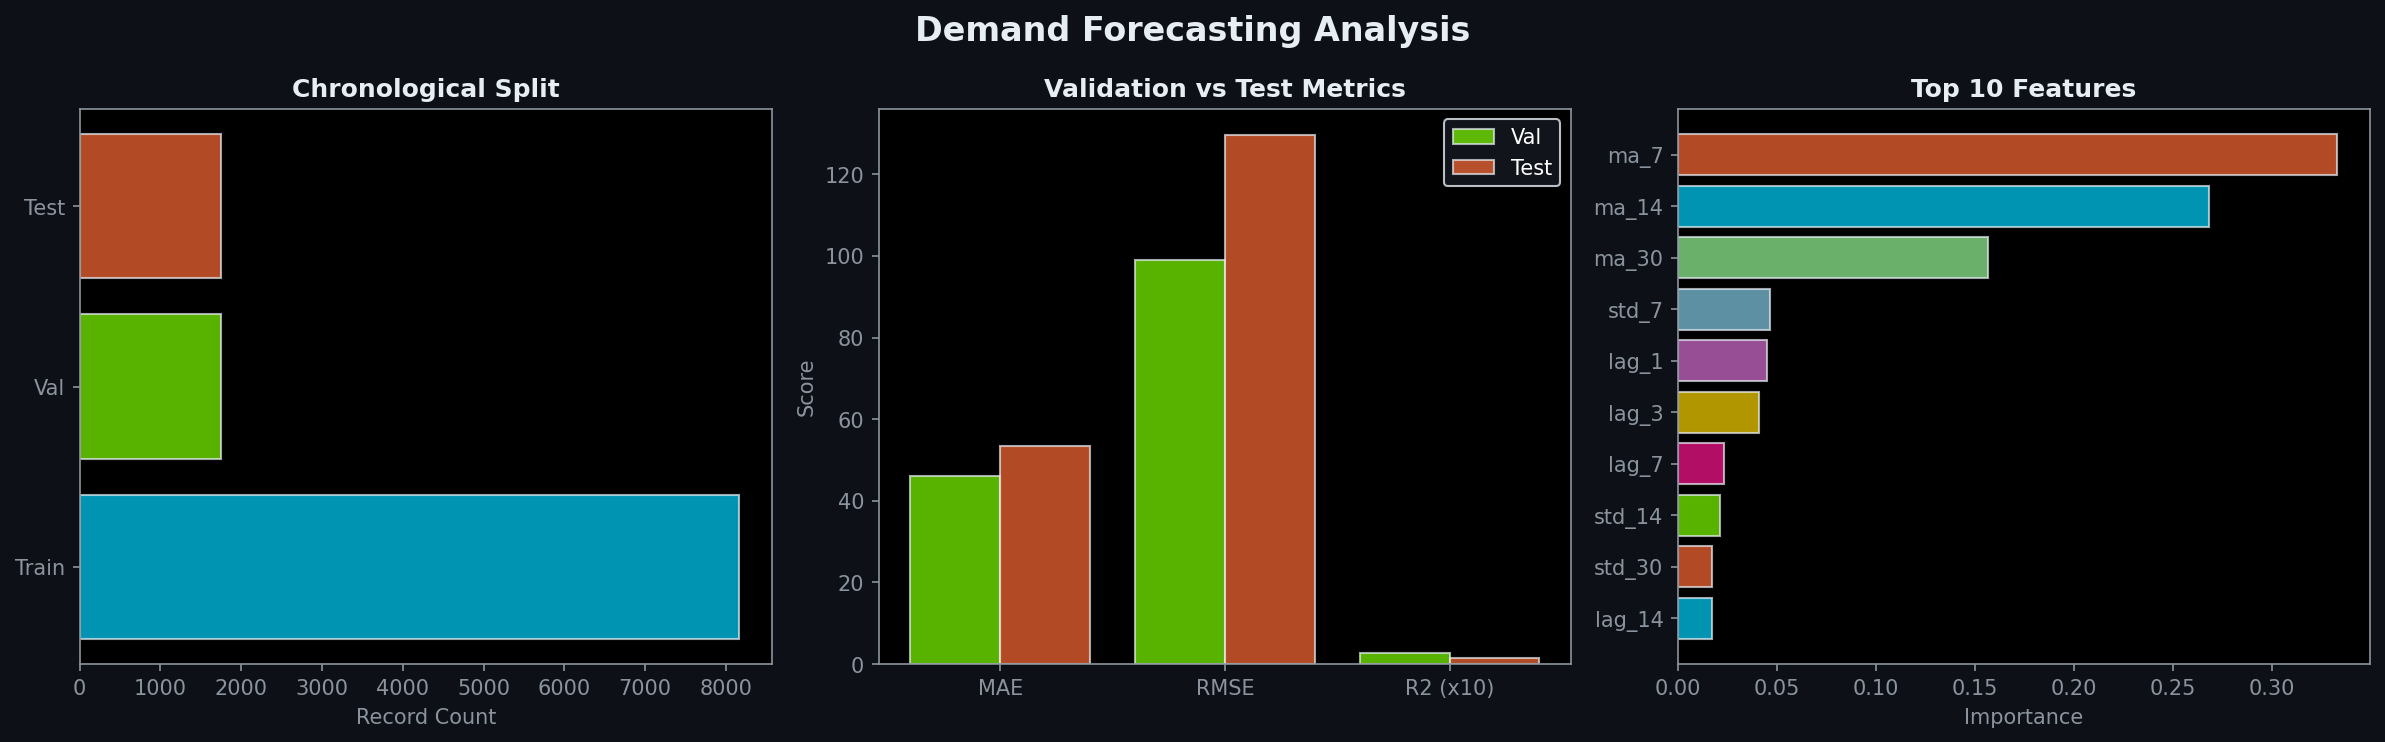

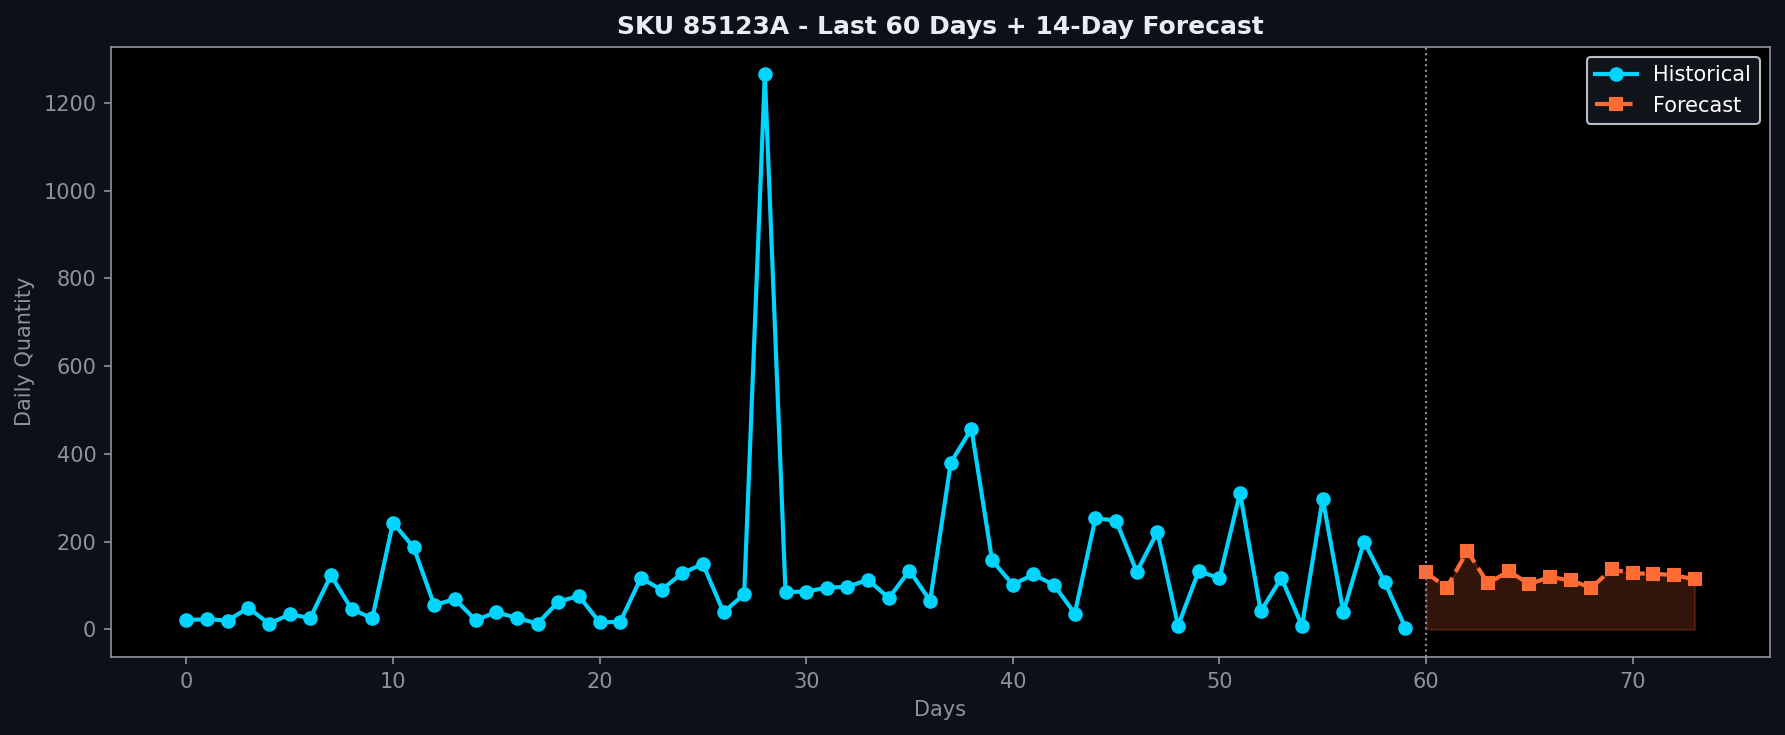


✅Subsystem 2 -- Demand Forecasting visualizations complete.


In [ ]:
# ============================================================================
#  Subsystem 2 -- AI Demand Forecasting (Random Forest)
#  Train / Validation / Test split: 70 / 15 / 15  (chronological, no shuffle)
# ============================================================================

LAGS             = [1, 3, 7, 14, 21]
WINDOWS          = [7, 14, 30]
FORECAST_HORIZON = 14   # days ahead to predict
TOP_N_SKUS       = 50   # focus on highest-volume SKUs

# Feature engineering: lag + rolling features per SKU ----------------------
def create_lag_features(ts, lags=[1,3,7,14,21], windows=[7,14,30]):
    df = ts.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['DailyQty'].shift(lag)
    for win in windows:
        df[f'ma_{win}'] = df['DailyQty'].rolling(win, min_periods=1).mean()
        df[f'std_{win}'] = df['DailyQty'].rolling(win, min_periods=1).std().fillna(0)
    df['dow'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    return df.bfill()

# Stack lag matrices for the top N SKUs into one training DataFrame --------
def build_training_data(daily_ts, top_n=TOP_N_SKUS):
    top_skus = daily_ts.groupby('StockCode')['DailyQty'].sum().nlargest(top_n).index.tolist()
    subset = daily_ts[daily_ts['StockCode'].isin(top_skus)].copy()
    training_data = []
    for sku in top_skus:
        sku_ts = subset[subset['StockCode'] == sku].sort_values('Date').reset_index(drop=True)
        sku_ts = create_lag_features(sku_ts)
        training_data.append(sku_ts)
    return pd.concat(training_data, ignore_index=True)

# Chronological 70 / 15 / 15 split ----------------------------------------
def chronological_split(df, train=0.70, val=0.15):
    """
    Split arrays chronologically to prevent data leakage.
      - Train : first 70% of rows
      - Val   : next  15% of rows
      - Test  : final 15% of rows
    No shuffling -- order must be preserved for time-series integrity.
    """
    n = len(df)
    t_idx = int(n * train)
    v_idx = int(n * (train + val))
    return df[:t_idx], df[t_idx:v_idx], df[v_idx:]

# Train Random Forest, evaluate on val then test ---------------------------
def train_forecast_model(X_train, y_train):
    model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    return model

# Recursive multi-step forecast for a single SKU ---------------------------
def forecast_sku(model, feature_cols, daily_df, sku, horizon=FORECAST_HORIZON):
    s = (daily_df[daily_df['StockCode'] == sku]
         .set_index('Date')['DailyQty'].sort_index())

    history_values = list(s.values)
    last_date = s.index[-1]

    preds = []
    forecast_dates = []

    for step in range(horizon):
        fut_date = last_date + pd.Timedelta(days=step + 1)

        row_features = {}

        for lag in LAGS:
            idx = len(history_values) - lag
            row_features[f'lag_{lag}'] = history_values[idx] if idx >= 0 else 0

        for win in WINDOWS:
            recent = history_values[-win:]
            row_features[f'ma_{win}'] = float(np.mean(recent)) if len(recent) > 0 else 0.0
            row_features[f'std_{win}'] = float(np.std(recent)) if len(recent) > 1 else 0.0

        row_features['dow'] = fut_date.dayofweek
        row_features['month'] = fut_date.month

        X_row = np.array([[row_features[c] for c in feature_cols]])

        pred  = float(np.maximum(0, model.predict(X_row))[0])
        preds.append(pred)
        forecast_dates.append(fut_date)

        history_values.append(pred)

    return pd.DataFrame({'date': forecast_dates, 'forecast': preds})

# Execute Subsystem 2 ------------------------------------------------------
print("=" * 70)
print(' [Subsystem 2] Demand Forecasting  (70 / 15 / 15 chronological split)')
print("=" * 70)

print('  \nBuilding training data (top 50 SKUs)...')
df_train = build_training_data(daily)
print(f'  Training data: {len(df_train):,} records')

# Replace the dynamic feature_cols definition with this explicit one
feature_cols = (
    [f'lag_{l}' for l in LAGS] +
    [f'ma_{w}'  for w in WINDOWS] +
    [f'std_{w}' for w in WINDOWS] +
    ['dow', 'month']
)
print(f'  Features ({len(feature_cols)}): {feature_cols}')

train_set, val_set, test_set = chronological_split(df_train.dropna())
print(f'  Split: Train {len(train_set):,} | Val {len(val_set):,} | Test {len(test_set):,}')

X_train = train_set[feature_cols]
y_train = train_set['DailyQty']
print('  Training Random Forest...')
rf_model = train_forecast_model(X_train, y_train)

# Validation metrics
X_val = val_set[feature_cols]
y_val = val_set['DailyQty']
y_val_pred = rf_model.predict(X_val)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

X_test = test_set[feature_cols]
y_test = test_set['DailyQty']
y_test_pred = rf_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f'  Validation: MAE={val_mae:.2f}, RMSE={val_rmse:.2f}, R2={val_r2:.3f}')
print(f'  Test:       MAE={test_mae:.2f}, RMSE={test_rmse:.2f}, R2={test_r2:.3f}')
print()

# Define metrics dictionary for later use in summary
metrics = {
    'val_mae': val_mae, 'val_rmse': val_rmse, 'val_r2': val_r2,
    'test_mae': test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2,
}

# Visualisation: Subsystem 2 ---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=FBG)
fig.suptitle('Demand Forecasting Analysis', fontsize=16, color=TC, fontweight='bold')

# Split timeline
splits = ['Train', 'Val', 'Test']
split_sizes = [len(train_set), len(val_set), len(test_set)]
colors_split = [COLORS[0], COLORS[2], COLORS[1]]
axes[0].barh(splits, split_sizes, color=colors_split, alpha=0.7, edgecolor=TC)
axes[0].set_xlabel('Record Count', color=MC)
axes[0].set_title('Chronological Split', color=TC, fontweight='bold')
axes[0].tick_params(colors=MC)
for spine in axes[0].spines.values():
    spine.set_color(MC)

# Metric comparison
metrics_labels = ['MAE', 'RMSE', 'R2 (x10)']
val_metrics_data = [val_mae, val_rmse, val_r2*10]
test_metrics_data = [test_mae, test_rmse, test_r2*10]
x = np.arange(len(metrics_labels))
axes[1].bar(x - 0.2, val_metrics_data, 0.4, label='Val', color=COLORS[2], alpha=0.7, edgecolor=TC)
axes[1].bar(x + 0.2, test_metrics_data, 0.4, label='Test', color=COLORS[1], alpha=0.7, edgecolor=TC)
axes[1].set_ylabel('Score', color=MC)
axes[1].set_title('Validation vs Test Metrics', color=TC, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_labels)
axes[1].legend(facecolor=ABG, edgecolor=TC)
axes[1].tick_params(colors=MC)
for spine in axes[1].spines.values():
    spine.set_color(MC)

# Feature importance
importances = rf_model.feature_importances_
feature_names = feature_cols
feat_import_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=True).tail(10)
colors_imp = [COLORS[i % len(COLORS)] for i in range(len(feat_import_df))]
axes[2].barh(feat_import_df['Feature'], feat_import_df['Importance'], color=colors_imp, alpha=0.7, edgecolor=TC)
axes[2].set_xlabel('Importance', color=MC)
axes[2].set_title('Top 10 Features', color=TC, fontweight='bold')
axes[2].tick_params(colors=MC)
for spine in axes[2].spines.values():
    spine.set_color(MC)

plt.tight_layout()
plt.savefig('/tmp/subsystem2_rf_model.png', facecolor=FBG, dpi=100, bbox_inches='tight')
plt.show()
print()

# Sample forecast for top SKU
top_sku = daily.groupby('StockCode')['DailyQty'].count().idxmax()  # most frequent, not highest volume
sku_history = daily[daily['StockCode'] == top_sku].sort_values('Date').tail(60).reset_index(drop=True)
forecast = forecast_sku(rf_model, feature_cols, daily, top_sku, horizon=FORECAST_HORIZON)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=FBG)
hist_dates = range(len(sku_history))
future_dates = range(len(sku_history), len(sku_history) + FORECAST_HORIZON)
ax.plot(hist_dates, sku_history['DailyQty'].values, color=COLORS[0], linewidth=2, marker='o', label='Historical')
ax.plot(future_dates, forecast['forecast'], color=COLORS[1], linewidth=2, marker='s', linestyle='--', label='Forecast')
ax.fill_between(future_dates, forecast['forecast'], alpha=0.2, color=COLORS[1])
ax.axvline(x=len(sku_history), color=MC, linestyle=':', linewidth=1)
ax.set_xlabel('Days', color=MC)
ax.set_ylabel('Daily Quantity', color=MC)
ax.set_title(f'SKU {top_sku} - Last 60 Days + 14-Day Forecast', color=TC, fontweight='bold')
ax.legend(facecolor=ABG, edgecolor=TC)
ax.tick_params(colors=MC)
for spine in ax.spines.values():
    spine.set_color(MC)

plt.tight_layout()
plt.savefig('/tmp/subsystem2_forecast.png', facecolor=FBG, dpi=100, bbox_inches='tight')
plt.show()
print('\n✅Subsystem 2 -- Demand Forecasting visualizations complete.')

---
## Cell 6 -- Subsystem 3: Anomaly Detection (Isolation Forest vs IQR)

**NASA Phase B (Preliminary Design)**  
**AI Technique chosen:** Isolation Forest  
**Compared against:** IQR (Interquartile Range) rule  

**Why Isolation Forest over IQR:**
- Evaluates 5 features jointly per transaction -- catches abnormal price-quantity combos IQR misses
- No distributional assumptions (IQR assumes roughly symmetric data)
- Unsupervised -- works without labelled fraud examples (none exist in this dataset)
- contamination=0.02 calibrated to the ~2% observed cancellation/return rate


 [Subsystem 3] Anomaly Detection
  Anomaly features: 530,104 records
  IQR flagged: 105,738 anomalies
  Isolation Forest flagged: 10,573 anomalies



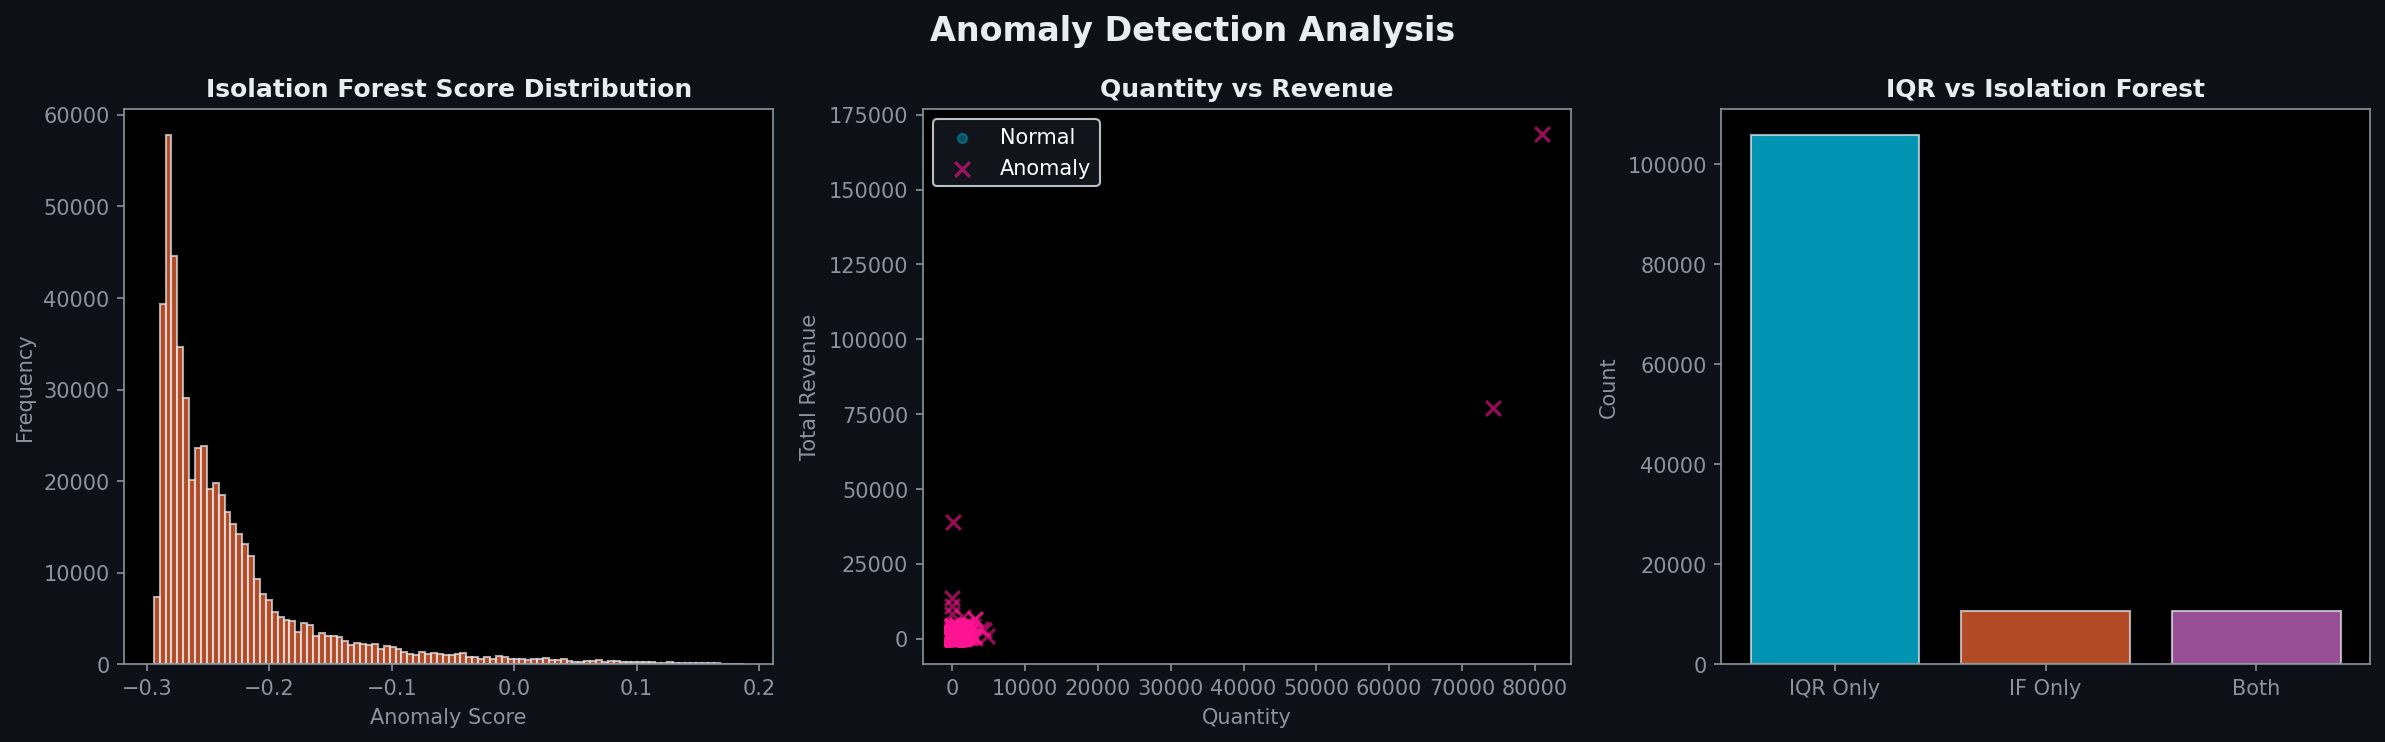


✅Subsystem 3 -- Anomaly Detection visualizations complete.


In [ ]:
# =====================================================================
#  Subsystem 3 -- Anomaly Detection (Isolation Forest vs IQR Baseline)
# =====================================================================

def build_anomaly_features(df):
    anom = df.copy()
    anom['QtyZScore_SKU'] = anom.groupby('StockCode')['Quantity'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))
    anom['PriceZScore_SKU'] = anom.groupby('StockCode')['UnitPrice'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))
    return anom[[
        'InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'TotalRevenue',
        'QtyZScore_SKU', 'PriceZScore_SKU', 'CustomerID', 'Country', 'InvoiceDate'
    ]]

def iqr_baseline(df):
    anomalies = []
    for col in ['Quantity', 'UnitPrice', 'TotalRevenue']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        anomalies.append(((df[col] < lower) | (df[col] > upper)).astype(int))
    return (sum(anomalies) > 0).astype(int)

def train_isolation_forest(feature_data, contamination=0.02):
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    iso_forest.fit(feature_data)
    return iso_forest

def detect_anomalies(df, iso_model):
    feature_cols = ['Quantity', 'UnitPrice', 'TotalRevenue', 'QtyZScore_SKU', 'PriceZScore_SKU']
    X = df[feature_cols].fillna(0)
    scores = iso_model.decision_function(X)
    pred = iso_model.predict(X)
    df['AnomalyScore'] = -scores
    df['IsAnomaly_IF'] = (pred == -1).astype(int)
    return df

# Execute Subsystem 3 ---------------------------------------------------
print("=" * 33)
print(' [Subsystem 3] Anomaly Detection')
print("=" * 33)

anom_df = build_anomaly_features(df_clean)
print(f'  Anomaly features: {len(anom_df):,} records')

# IQR baseline
anom_df['IsAnomaly_IQR'] = iqr_baseline(anom_df)
iqr_count = anom_df['IsAnomaly_IQR'].sum()
print(f'  IQR flagged: {iqr_count:,} anomalies')

# Isolation Forest
feature_cols = ['Quantity', 'UnitPrice', 'TotalRevenue', 'QtyZScore_SKU', 'PriceZScore_SKU']
X_anom = anom_df[feature_cols].fillna(0)
iso_model = train_isolation_forest(X_anom, contamination=0.02)
anom_df = detect_anomalies(anom_df, iso_model)
if_count = anom_df['IsAnomaly_IF'].sum()
print(f'  Isolation Forest flagged: {if_count:,} anomalies')
print()

# Visualisation: Subsystem 3 ---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=FBG)
fig.suptitle('Anomaly Detection Analysis', fontsize=16, color=TC, fontweight='bold')

# Score distribution
axes[0].hist(anom_df['AnomalyScore'], bins=100, color=COLORS[1], alpha=0.7, edgecolor=TC)
axes[0].set_xlabel('Anomaly Score', color=MC)
axes[0].set_ylabel('Frequency', color=MC)
axes[0].set_title('Isolation Forest Score Distribution', color=TC, fontweight='bold')
axes[0].tick_params(colors=MC)
for spine in axes[0].spines.values():
    spine.set_color(MC)

# Scatter: Qty vs Revenue
normal = anom_df[anom_df['IsAnomaly_IF'] == 0]
anomalies = anom_df[anom_df['IsAnomaly_IF'] == 1]
axes[1].scatter(normal['Quantity'], normal['TotalRevenue'], alpha=0.3, s=20, color=COLORS[0], label='Normal')
axes[1].scatter(anomalies['Quantity'], anomalies['TotalRevenue'], alpha=0.6, s=50, color=COLORS[3], marker='x', label='Anomaly')
axes[1].set_xlabel('Quantity', color=MC)
axes[1].set_ylabel('Total Revenue', color=MC)
axes[1].set_title('Quantity vs Revenue', color=TC, fontweight='bold')
axes[1].legend(facecolor=ABG, edgecolor=TC)
axes[1].tick_params(colors=MC)
for spine in axes[1].spines.values():
    spine.set_color(MC)

# IQR vs IF comparison
comp_data = [
    anom_df['IsAnomaly_IQR'].sum(),
    anom_df['IsAnomaly_IF'].sum(),
    (anom_df['IsAnomaly_IQR'] & anom_df['IsAnomaly_IF']).sum()
]
comp_labels = ['IQR Only', 'IF Only', 'Both']
axes[2].bar(comp_labels, comp_data, color=[COLORS[0], COLORS[1], COLORS[5]], alpha=0.7, edgecolor=TC)
axes[2].set_ylabel('Count', color=MC)
axes[2].set_title('IQR vs Isolation Forest', color=TC, fontweight='bold')
axes[2].tick_params(colors=MC)
for spine in axes[2].spines.values():
    spine.set_color(MC)

plt.tight_layout()
plt.savefig('/tmp/subsystem3_anomaly_detection.png', facecolor=FBG, dpi=100, bbox_inches='tight')
plt.show()
print('\n✅Subsystem 3 -- Anomaly Detection visualizations complete.')

---
## Cell 7 -- Subsystem 4: Customer Segmentation (K-Means on RFM)


 [Subsystem 4] Customer Segmentation
  RFM computed for 4,338 customers
  Recency: 1 ~ 374 days
  Frequency: 1 ~ 7847 purchases
  Monetary: £3.75 ~ £280206.02
  Optimal k (silhouette): 2
  Using k=4 (standard RFM segmentation)
  Segments: {'Potential': 2507, 'VIP': 934, 'Churn Risk': 897}



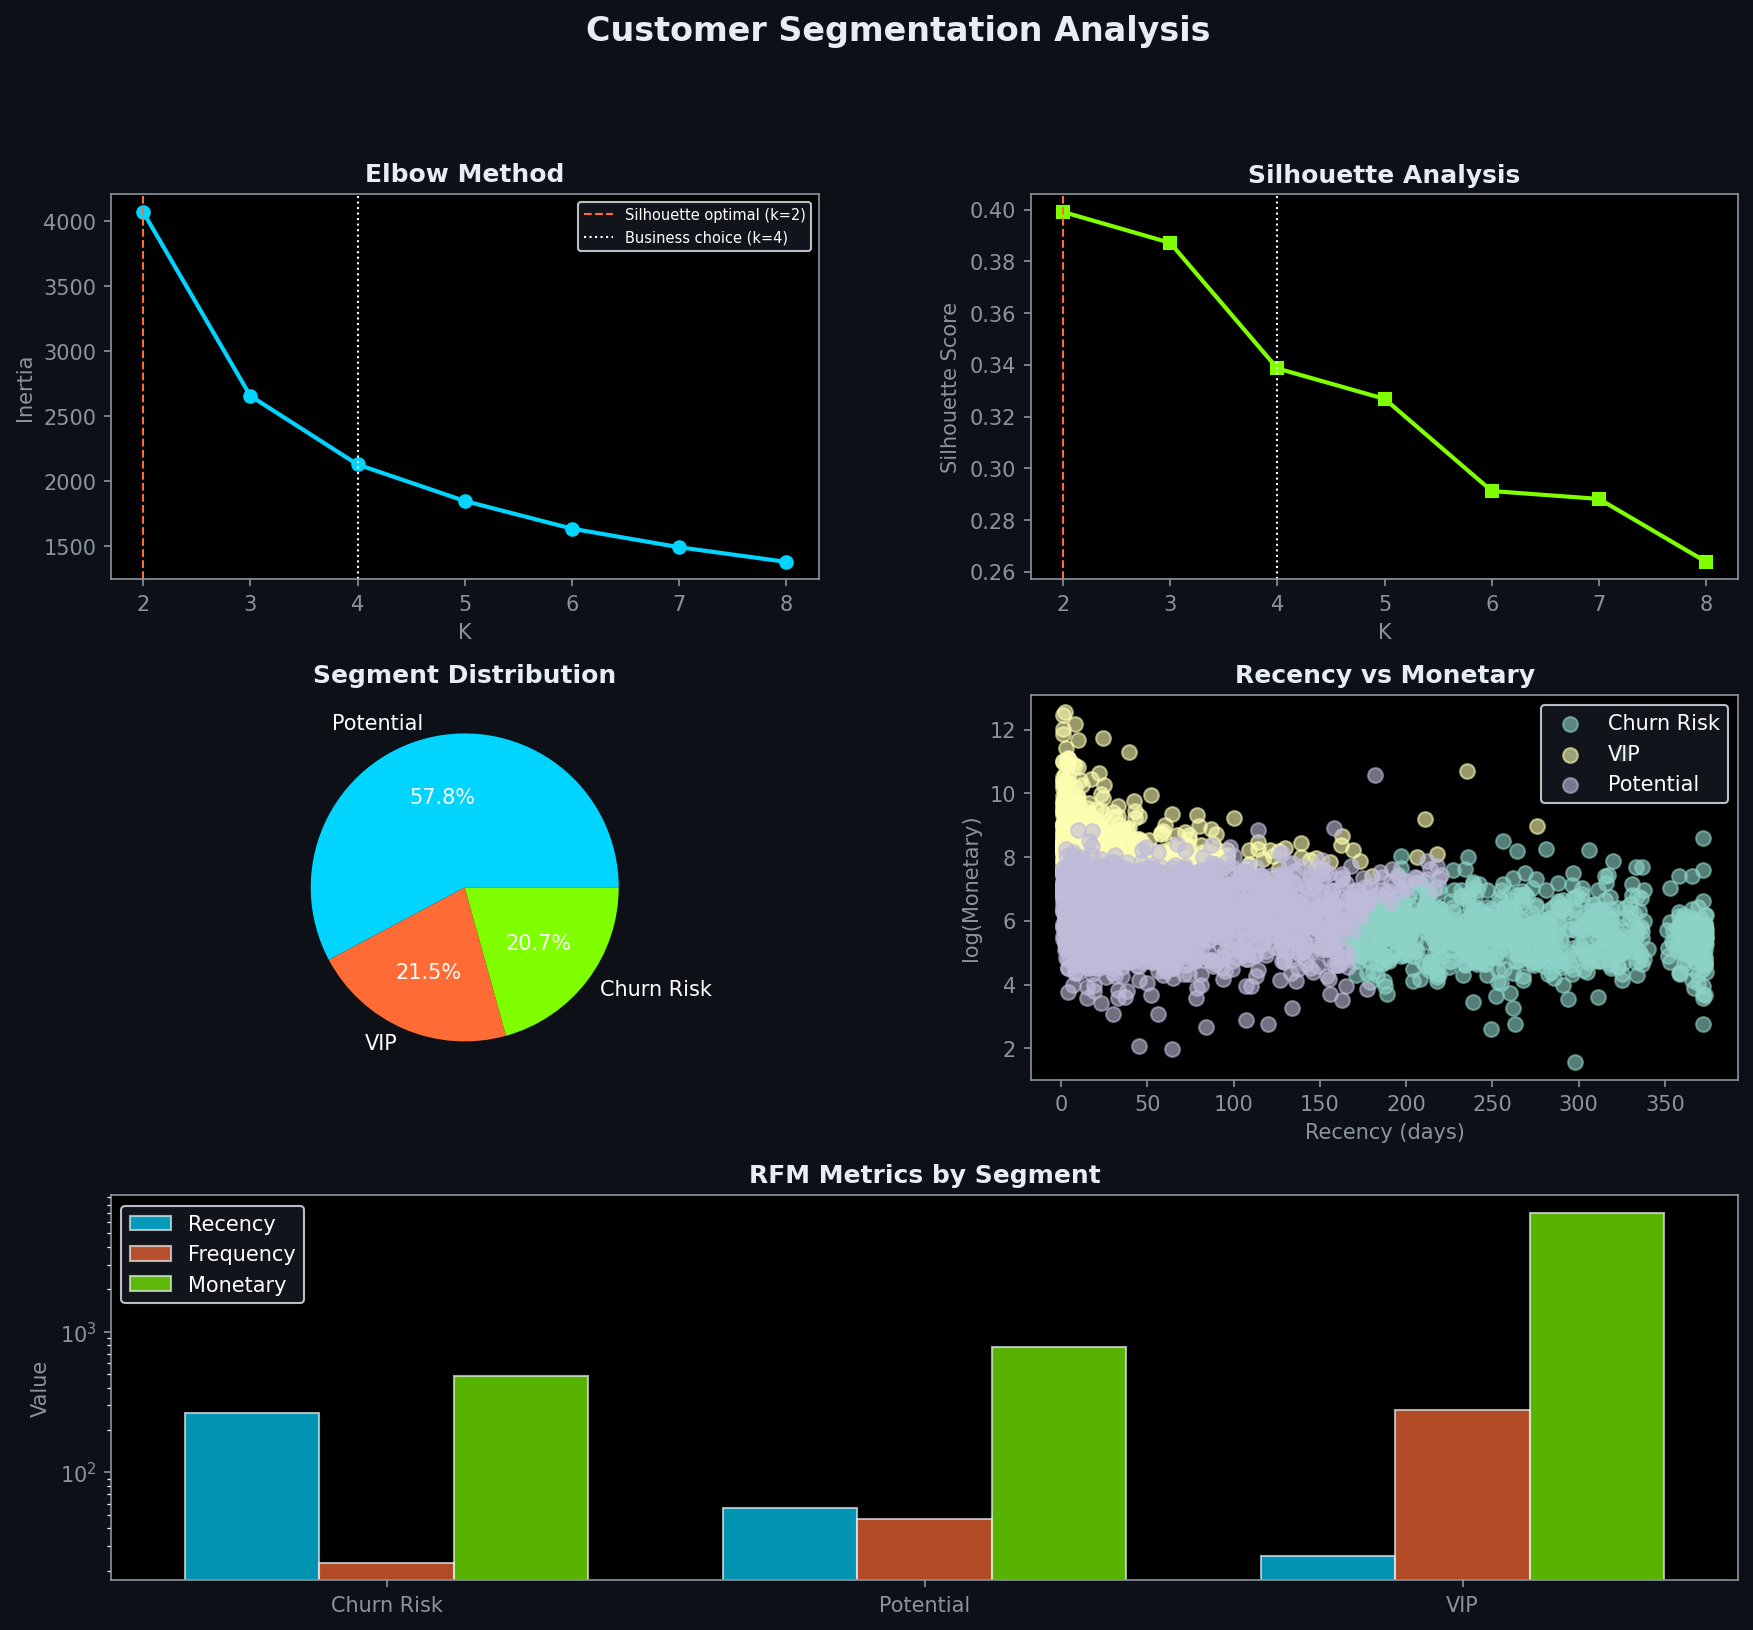


✅Subsystem 4 -- Customer Segmentation visualizations complete.


In [ ]:
# ======================================================
#  Subsystem 4 -- Customer Segmentation (RFM + K-Means)
# ======================================================
from sklearn.preprocessing import RobustScaler

def compute_rfm(df):
    ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (ref_date - x.max()).days,
        'InvoiceNo': 'count',
        'TotalRevenue': 'sum'
    }).reset_index()
    rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
    rfm['Monetary'] = rfm['Monetary'].round(2)
    return rfm

def find_optimal_k(rfm_scaled, k_range=range(2, 9)):
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(rfm_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(rfm_scaled, labels))
    return list(k_range), inertias, silhouettes

def train_kmeans(rfm_scaled, n_clusters=4):
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    return km.fit_predict(rfm_scaled), km

# Execute Subsystem 4 ---------------------------------------------------
print("=" * 37)
print(' [Subsystem 4] Customer Segmentation')
print("=" * 37)

rfm = compute_rfm(df_seg)
print(f'  RFM computed for {len(rfm):,} customers')
print(f'  Recency: {rfm["Recency"].min():.0f} ~ {rfm["Recency"].max():.0f} days')
print(f'  Frequency: {rfm["Frequency"].min():.0f} ~ {rfm["Frequency"].max():.0f} purchases')
print(f'  Monetary: £{rfm["Monetary"].min():.2f} ~ £{rfm["Monetary"].max():.2f}')

# Scale RFM features (RobustScaler)
# Log-transform Frequency and Monetary to compress extreme outliers
rfm['log_Frequency'] = np.log1p(rfm['Frequency'])
rfm['log_Monetary']  = np.log1p(rfm['Monetary'])

scaler = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'log_Frequency', 'log_Monetary']])

# Find optimal k (for diagnostic charts only)
k_range, inertias, silhouettes = find_optimal_k(rfm_scaled)
optimal_k = k_range[np.argmax(silhouettes)]
print(f'  Optimal k (silhouette): {optimal_k}')

# Train with k=4
# Business decision: use k=4 for standard 4-segment RFM framework
business_k = 4
print(f'  Using k={business_k} (standard RFM segmentation)')
labels, kmeans_model = train_kmeans(rfm_scaled, n_clusters=business_k)
rfm['Segment'] = labels

# Label segments
segment_stats = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
segment_names = {}
for seg in segment_stats.index:
    rec  = segment_stats.loc[seg, 'Recency']
    freq = segment_stats.loc[seg, 'Frequency']
    mon  = segment_stats.loc[seg, 'Monetary']

    if mon > rfm['Monetary'].quantile(0.75) and freq > rfm['Frequency'].quantile(0.75):
        segment_names[seg] = 'VIP'
    elif rec <= rfm['Recency'].quantile(0.33) and freq >= rfm['Frequency'].quantile(0.50):
        segment_names[seg] = 'Active'
    elif rec >= rfm['Recency'].quantile(0.66):
        segment_names[seg] = 'Churn Risk'
    else:
        segment_names[seg] = 'Potential'
rfm['SegmentName'] = rfm['Segment'].map(segment_names)
print(f'  Segments: {rfm["SegmentName"].value_counts().to_dict()}')
print()

# Visualisation: Subsystem 4 ---------------------------------------------------
fig = plt.figure(figsize=(14, 12), facecolor=FBG)
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
fig.suptitle('Customer Segmentation Analysis', fontsize=16, color=TC, fontweight='bold')

# Elbow method
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(k_range, inertias, color=COLORS[0], linewidth=2, marker='o')
ax1.axvline(x=optimal_k, color=COLORS[1], linestyle='--', linewidth=1, label=f'Silhouette optimal (k={optimal_k})')
ax1.axvline(x=business_k, color='white', linestyle=':', linewidth=1, label=f'Business choice (k={business_k})')
ax1.legend(facecolor=ABG, edgecolor=TC, fontsize=7)
ax1.set_xlabel('K', color=MC)
ax1.set_ylabel('Inertia', color=MC)
ax1.set_title('Elbow Method', color=TC, fontweight='bold')
ax1.tick_params(colors=MC)
for spine in ax1.spines.values():
    spine.set_color(MC)

# Silhouette score
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(k_range, silhouettes, color=COLORS[2], linewidth=2, marker='s')
ax2.axvline(x=optimal_k, color=COLORS[1], linestyle='--', linewidth=1, label=f'Silhouette optimal (k={optimal_k})')
ax2.axvline(x=business_k, color='white', linestyle=':', linewidth=1, label=f'Business choice (k={business_k})')
ax2.set_xlabel('K', color=MC)
ax2.set_ylabel('Silhouette Score', color=MC)
ax2.set_title('Silhouette Analysis', color=TC, fontweight='bold')
ax2.tick_params(colors=MC)
for spine in ax2.spines.values():
    spine.set_color(MC)

# Segment pie
ax3 = fig.add_subplot(gs[1, 0])
seg_counts = rfm['SegmentName'].value_counts()
ax3.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%', colors=COLORS[:len(seg_counts)])
ax3.set_title('Segment Distribution', color=TC, fontweight='bold')

# Recency vs Monetary scatter
ax4 = fig.add_subplot(gs[1, 1])
for seg_name in rfm['SegmentName'].unique():
    seg_data = rfm[rfm['SegmentName'] == seg_name]
    ax4.scatter(seg_data['Recency'], np.log1p(seg_data['Monetary']), s=50, alpha=0.6, label=seg_name)
ax4.set_xlabel('Recency (days)', color=MC)
ax4.set_ylabel('log(Monetary)', color=MC)
ax4.set_title('Recency vs Monetary', color=TC, fontweight='bold')
ax4.legend(facecolor=ABG, edgecolor=TC, loc='best')
ax4.tick_params(colors=MC)
for spine in ax4.spines.values():
    spine.set_color(MC)

# RFM stats by segment
ax5 = fig.add_subplot(gs[2, :])
seg_stats = rfm.groupby('SegmentName')[['Recency', 'Frequency', 'Monetary']].mean()
x = np.arange(len(seg_stats))
width = 0.25
ax5.bar(x - width, seg_stats['Recency'], width, label='Recency', color=COLORS[0], alpha=0.7, edgecolor=TC)
ax5.bar(x, seg_stats['Frequency'], width, label='Frequency', color=COLORS[1], alpha=0.7, edgecolor=TC)
ax5.bar(x + width, seg_stats['Monetary'], width, label='Monetary', color=COLORS[2], alpha=0.7, edgecolor=TC)
ax5.set_ylabel('Value', color=MC)
ax5.set_title('RFM Metrics by Segment', color=TC, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(seg_stats.index)
ax5.set_yscale('log')
ax5.legend(facecolor=ABG, edgecolor=TC)
ax5.tick_params(colors=MC)
for spine in ax5.spines.values():
    spine.set_color(MC)

plt.savefig('/tmp/subsystem4_customer_segmentation.png', facecolor=FBG, dpi=100, bbox_inches='tight')
plt.show()
print('\n✅Subsystem 4 -- Customer Segmentation visualizations complete.')

---
## Cell 8 -- Subsystem 5: Fuzzy Logic Reorder System



 [Subsystem 5] Fuzzy Logic Reorder System
  Pre-computing fuzzy grid (51x31 = 1,581 evaluations)...
  Grid complete. Running vectorized scoring...
  Fuzzy alerts for 3,922 SKUs:
    CRITICAL  : 2,649
    MONITOR   :    71
    OK        :    37

Top 10 CRITICAL alerts:
     StockCode                          Description  Coverage  DemandCV  FuzzyPriority AlertLevel
3852    90201B             BLACK ENAMEL FLOWER RING  0.314286  1.041096      90.714286   CRITICAL
2984    84510E     SET OF 4 GREEN CAROUSEL COASTERS  0.228571  1.043462      90.714286   CRITICAL
3346     85045  GREEN CHRISTMAS TREE STRING 20LIGHT  0.142857  1.690309      90.714286   CRITICAL
3365     85055         FRENCH ENAMEL UTENSIL HOLDER  0.185714  1.522344      90.714286   CRITICAL
3360    85049d                BRIGHT BLUES RIBBONS   0.028571  0.000000      90.714286   CRITICAL
3358    85049b                  LUSH GREENS RIBBONS  0.028571  0.000000      90.714286   CRITICAL
3330    85035a  GARDENIA 3 WICK MORRIS BOXED 

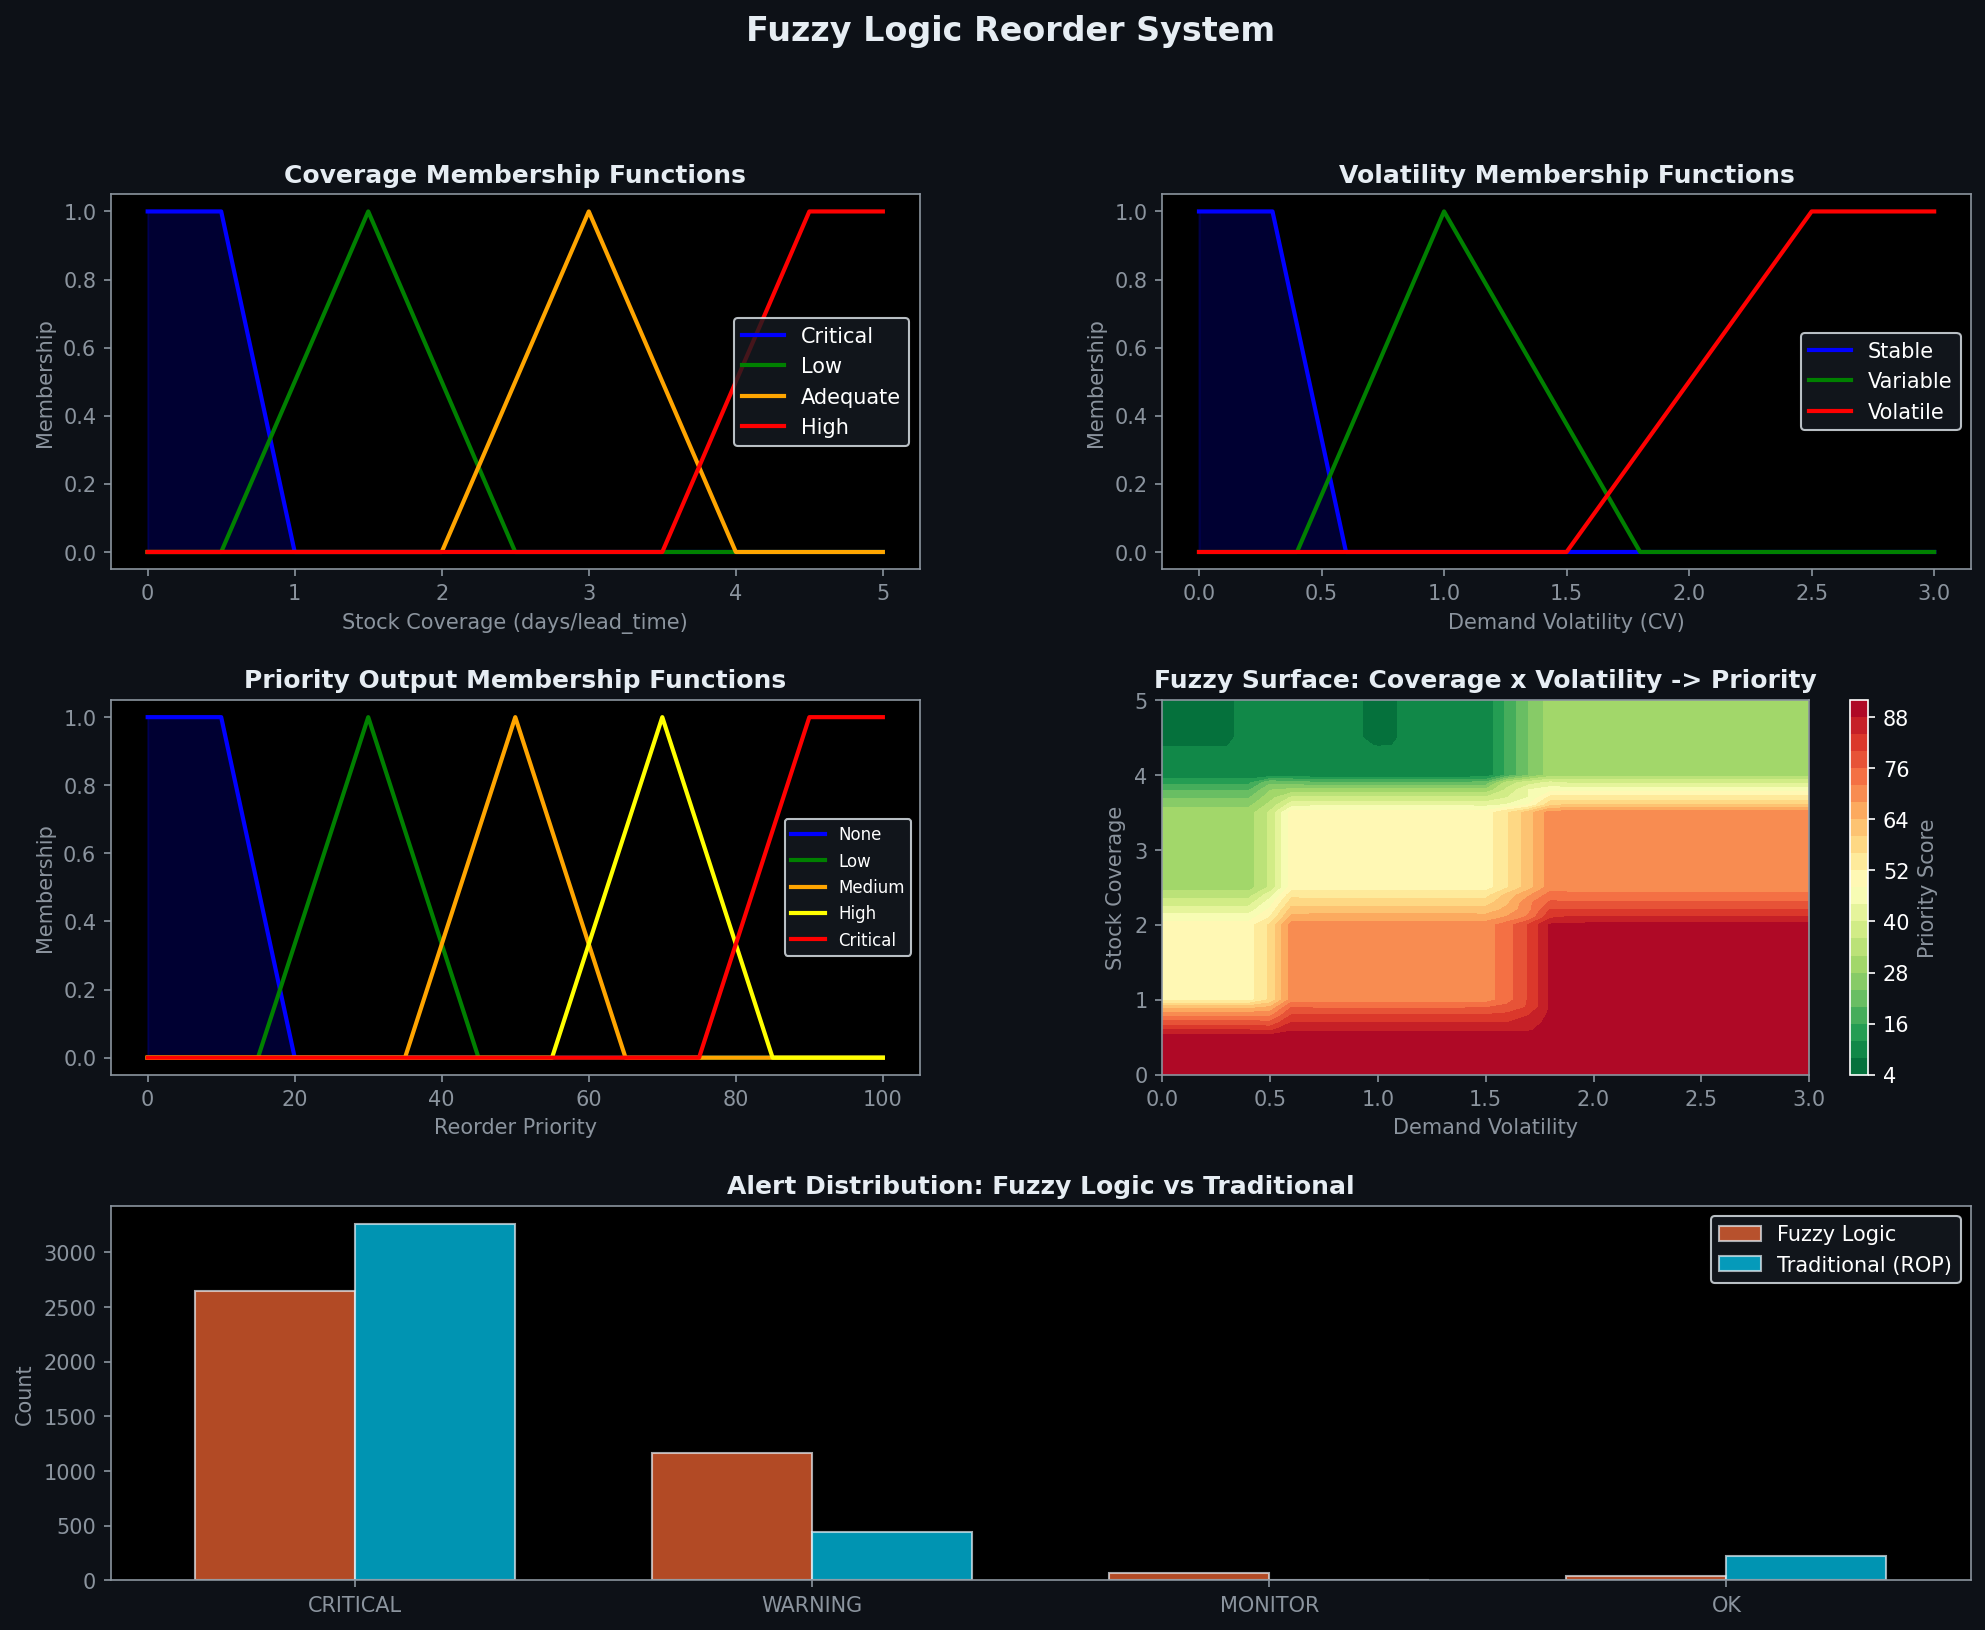


✅Subsystem 5 -- Fuzzy Logic Reorder System visualizations complete.


In [ ]:
# ===========================================
#  Subsystem 5 -- Fuzzy Logic Reorder System
# ===========================================

LEAD_TIME    = 7      # days

def build_fuzzy_reorder_system():
    cov_universe = np.arange(0, 5.05, 0.05)
    vol_universe = np.arange(0, 3.05, 0.05)
    pri_universe = np.arange(0, 101, 1)

    coverage   = ctrl.Antecedent(cov_universe, 'coverage')
    volatility = ctrl.Antecedent(vol_universe, 'volatility')
    priority   = ctrl.Consequent(pri_universe, 'priority')

    coverage['critical'] = fuzz.trapmf(coverage.universe, [0, 0, 0.5, 1.0])
    coverage['low']      = fuzz.trimf(coverage.universe,  [0.5, 1.5, 2.5])
    coverage['adequate'] = fuzz.trimf(coverage.universe,  [2.0, 3.0, 4.0])
    coverage['high']     = fuzz.trapmf(coverage.universe, [3.5, 4.5, 5, 5])

    volatility['stable']   = fuzz.trapmf(volatility.universe, [0, 0, 0.3, 0.6])
    volatility['variable'] = fuzz.trimf(volatility.universe,  [0.4, 1.0, 1.8])
    volatility['volatile'] = fuzz.trapmf(volatility.universe, [1.5, 2.5, 3, 3])

    priority['none']     = fuzz.trapmf(priority.universe, [0, 0, 10, 20])
    priority['low']      = fuzz.trimf(priority.universe,  [15, 30, 45])
    priority['medium']   = fuzz.trimf(priority.universe,  [35, 50, 65])
    priority['high']     = fuzz.trimf(priority.universe,  [55, 70, 85])
    priority['critical'] = fuzz.trapmf(priority.universe, [75, 90, 100, 100])

    rules = [
        ctrl.Rule(coverage['critical'],                          priority['critical']),
        ctrl.Rule(coverage['low']      & volatility['volatile'], priority['critical']),
        ctrl.Rule(coverage['low']      & volatility['variable'], priority['high']),
        ctrl.Rule(coverage['low']      & volatility['stable'],   priority['medium']),
        ctrl.Rule(coverage['adequate'] & volatility['volatile'], priority['high']),
        ctrl.Rule(coverage['adequate'] & volatility['variable'], priority['medium']),
        ctrl.Rule(coverage['adequate'] & volatility['stable'],   priority['low']),
        ctrl.Rule(coverage['high']     & volatility['volatile'], priority['low']),
        ctrl.Rule(coverage['high']     & volatility['variable'], priority['none']),
        ctrl.Rule(coverage['high']     & volatility['stable'],   priority['none']),
    ]
    system = ctrl.ControlSystem(rules)
    return coverage, volatility, priority, system

def precompute_fuzzy_grid(system):
    cov_pts = np.arange(0, 5.1, 0.1)
    vol_pts = np.arange(0, 3.1, 0.1)
    grid = np.zeros((len(cov_pts), len(vol_pts)))
    sim = ctrl.ControlSystemSimulation(system)
    for i, c in enumerate(cov_pts):
        for j, v in enumerate(vol_pts):
            try:
                sim.input['coverage']   = float(c)
                sim.input['volatility'] = float(v)
                sim.compute()
                grid[i, j] = sim.output['priority']
            except:
                grid[i, j] = 50.0
    interp = RegularGridInterpolator((cov_pts, vol_pts), grid,
                                      method='linear', bounds_error=False, fill_value=None)
    return interp, cov_pts, vol_pts, grid

def compute_fuzzy_alerts(daily_ts, inv_data, lead_time=LEAD_TIME):
    sku_dem = (daily_ts.groupby('StockCode')['DailyQty']
                    .agg(Avg='mean', Std='std').fillna(0).reset_index())
    params = inv_data.merge(sku_dem, on='StockCode', how='left').fillna(0)
    params['EstCurrentStock'] = params['TotalQty'] * 0.1

    params['Coverage'] = np.where(
        params['Avg'] > 0,
        (params['EstCurrentStock'] / (params['Avg'] * lead_time)).clip(0, 5), 5.0)

    params['DemandCV'] = np.where(
        params['Avg'] > 0.01,
        (params['Std'] / params['Avg']).clip(0, 3), 0.0)

    params['SafetyStock'] = (1.645 * params['Std'] * math.sqrt(lead_time)).round(1)
    params['ROP']         = (params['Avg'] * lead_time + params['SafetyStock']).round(1)
    ann = params['Avg'] * 365
    hpu = params['AvgUnitPrice'] * 0.25
    params['EOQ'] = np.where(hpu > 0, np.sqrt(2 * ann * 50 / hpu), 0).round(0)

    points = np.column_stack([params['Coverage'].values.clip(0, 5),
                               params['DemandCV'].values.clip(0, 3)])
    params['FuzzyPriority'] = interp_fn(points)

    def alert_level(score):
        if score >= 75: return 'CRITICAL'
        if score >= 50: return 'WARNING'
        if score >= 25: return 'MONITOR'
        return 'OK'

    params['AlertLevel']    = params['FuzzyPriority'].apply(alert_level)

    def trad_level(row):
        if row['EstCurrentStock'] < row['ROP']:       return 'CRITICAL'
        if row['EstCurrentStock'] < row['ROP'] * 1.5: return 'WARNING'
        return 'OK'
    params['TradAlertLevel'] = params.apply(trad_level, axis=1)

    print(f'  Fuzzy alerts for {len(params):,} SKUs:')
    for lvl, cnt in params['AlertLevel'].value_counts().items():
        print(f'    {lvl:<10}: {cnt:>5,}')
    return params

# Execute Subsystem 5 ---------------------------------------------------
print("=" * 42)
print(' [Subsystem 5] Fuzzy Logic Reorder System')
print("=" * 42)

coverage_var, volatility_var, priority_var, fuzzy_system = build_fuzzy_reorder_system()
print('  Pre-computing fuzzy grid (51x31 = 1,581 evaluations)...')
interp_fn, cov_pts, vol_pts, fuzzy_grid = precompute_fuzzy_grid(fuzzy_system)
print('  Grid complete. Running vectorized scoring...')
alerts = compute_fuzzy_alerts(daily, inv)
print()
print('Top 10 CRITICAL alerts:')
critical_alerts = alerts[alerts['AlertLevel']=='CRITICAL'].sort_values('FuzzyPriority', ascending=False).head(10)
print(critical_alerts[['StockCode','Description','Coverage','DemandCV','FuzzyPriority','AlertLevel']].to_string())

# Export alerts to CSV
alerts.to_csv('/content/smartWH_fuzzy_reorder.csv', index=False)
print('Alerts exported to /content/smartWH_fuzzy_reorder.csv\n')

# Visualisation: Subsystem 5 ---------------------------------------------------
fig = plt.figure(figsize=(16, 12), facecolor=FBG)
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
fig.suptitle('Fuzzy Logic Reorder System', fontsize=16, color=TC, fontweight='bold')

# Coverage membership functions
ax1 = fig.add_subplot(gs[0, 0])
x = coverage_var.universe
ax1.plot(x, fuzz.trapmf(x, [0, 0, 0.5, 1.0]), 'b', linewidth=2, label='Critical')
ax1.plot(x, fuzz.trimf(x, [0.5, 1.5, 2.5]), 'g', linewidth=2, label='Low')
ax1.plot(x, fuzz.trimf(x, [2.0, 3.0, 4.0]), 'orange', linewidth=2, label='Adequate')
ax1.plot(x, fuzz.trapmf(x, [3.5, 4.5, 5, 5]), 'r', linewidth=2, label='High')
ax1.fill_between(x, 0, fuzz.trapmf(x, [0, 0, 0.5, 1.0]), alpha=0.2, color='b')
ax1.set_xlabel('Stock Coverage (days/lead_time)', color=MC)
ax1.set_ylabel('Membership', color=MC)
ax1.set_title('Coverage Membership Functions', color=TC, fontweight='bold')
ax1.legend(facecolor=ABG, edgecolor=TC, loc='best')
ax1.tick_params(colors=MC)
for spine in ax1.spines.values():
    spine.set_color(MC)

# Volatility membership functions
ax2 = fig.add_subplot(gs[0, 1])
x = volatility_var.universe
ax2.plot(x, fuzz.trapmf(x, [0, 0, 0.3, 0.6]), 'b', linewidth=2, label='Stable')
ax2.plot(x, fuzz.trimf(x, [0.4, 1.0, 1.8]), 'g', linewidth=2, label='Variable')
ax2.plot(x, fuzz.trapmf(x, [1.5, 2.5, 3, 3]), 'r', linewidth=2, label='Volatile')
ax2.fill_between(x, 0, fuzz.trapmf(x, [0, 0, 0.3, 0.6]), alpha=0.2, color='b')
ax2.set_xlabel('Demand Volatility (CV)', color=MC)
ax2.set_ylabel('Membership', color=MC)
ax2.set_title('Volatility Membership Functions', color=TC, fontweight='bold')
ax2.legend(facecolor=ABG, edgecolor=TC, loc='best')
ax2.tick_params(colors=MC)
for spine in ax2.spines.values():
    spine.set_color(MC)

# Priority membership functions
ax3 = fig.add_subplot(gs[1, 0])
x = priority_var.universe
ax3.plot(x, fuzz.trapmf(x, [0, 0, 10, 20]), 'b', linewidth=2, label='None')
ax3.plot(x, fuzz.trimf(x, [15, 30, 45]), 'g', linewidth=2, label='Low')
ax3.plot(x, fuzz.trimf(x, [35, 50, 65]), 'orange', linewidth=2, label='Medium')
ax3.plot(x, fuzz.trimf(x, [55, 70, 85]), 'yellow', linewidth=2, label='High')
ax3.plot(x, fuzz.trapmf(x, [75, 90, 100, 100]), 'r', linewidth=2, label='Critical')
ax3.fill_between(x, 0, fuzz.trapmf(x, [0, 0, 10, 20]), alpha=0.2, color='b')
ax3.set_xlabel('Reorder Priority', color=MC)
ax3.set_ylabel('Membership', color=MC)
ax3.set_title('Priority Output Membership Functions', color=TC, fontweight='bold')
ax3.legend(facecolor=ABG, edgecolor=TC, loc='best', fontsize=8)
ax3.tick_params(colors=MC)
for spine in ax3.spines.values():
    spine.set_color(MC)

# Heatmap of coverage vs volatility -> priority
ax4 = fig.add_subplot(gs[1, 1])
im = ax4.contourf(vol_pts, cov_pts, fuzzy_grid, levels=20, cmap='RdYlGn_r')
ax4.set_xlabel('Demand Volatility', color=MC)
ax4.set_ylabel('Stock Coverage', color=MC)
ax4.set_title('Fuzzy Surface: Coverage x Volatility -> Priority', color=TC, fontweight='bold')
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('Priority Score', color=MC)
ax4.tick_params(colors=MC)
for spine in ax4.spines.values():
    spine.set_color(MC)

# Alert distribution comparison
ax5 = fig.add_subplot(gs[2, :])
fuzzy_counts = alerts['AlertLevel'].value_counts().reindex(['CRITICAL', 'WARNING', 'MONITOR', 'OK'], fill_value=0)
trad_counts = alerts['TradAlertLevel'].value_counts().reindex(['CRITICAL', 'WARNING', 'OK'], fill_value=0)
x = np.arange(len(fuzzy_counts))
width = 0.35
colors_alert = ['red', 'orange', 'yellow', 'green']
ax5.bar(x - width/2, fuzzy_counts.values, width, label='Fuzzy Logic', color=COLORS[1], alpha=0.7, edgecolor=TC)
ax5.bar(x + width/2, [trad_counts.get(l, 0) for l in fuzzy_counts.index], width, label='Traditional (ROP)', color=COLORS[0], alpha=0.7, edgecolor=TC)
ax5.set_ylabel('Count', color=MC)
ax5.set_title('Alert Distribution: Fuzzy Logic vs Traditional', color=TC, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(fuzzy_counts.index)
ax5.legend(facecolor=ABG, edgecolor=TC)
ax5.tick_params(colors=MC)
for spine in ax5.spines.values():
    spine.set_color(MC)

plt.savefig('/tmp/subsystem5_fuzzy_reorder_system.png', facecolor=FBG, dpi=100, bbox_inches='tight')
plt.show()
print('\n✅Subsystem 5 -- Fuzzy Logic Reorder System visualizations complete.')

---
## Cell 9 -- Subsystem 6: Visualisation Dashboard

**NASA Phase E (Operations & Sustainment)**

All seven charts are rendered inline using Matplotlib (dark theme).
These charts would appear in the browser-based GUI when running locally.


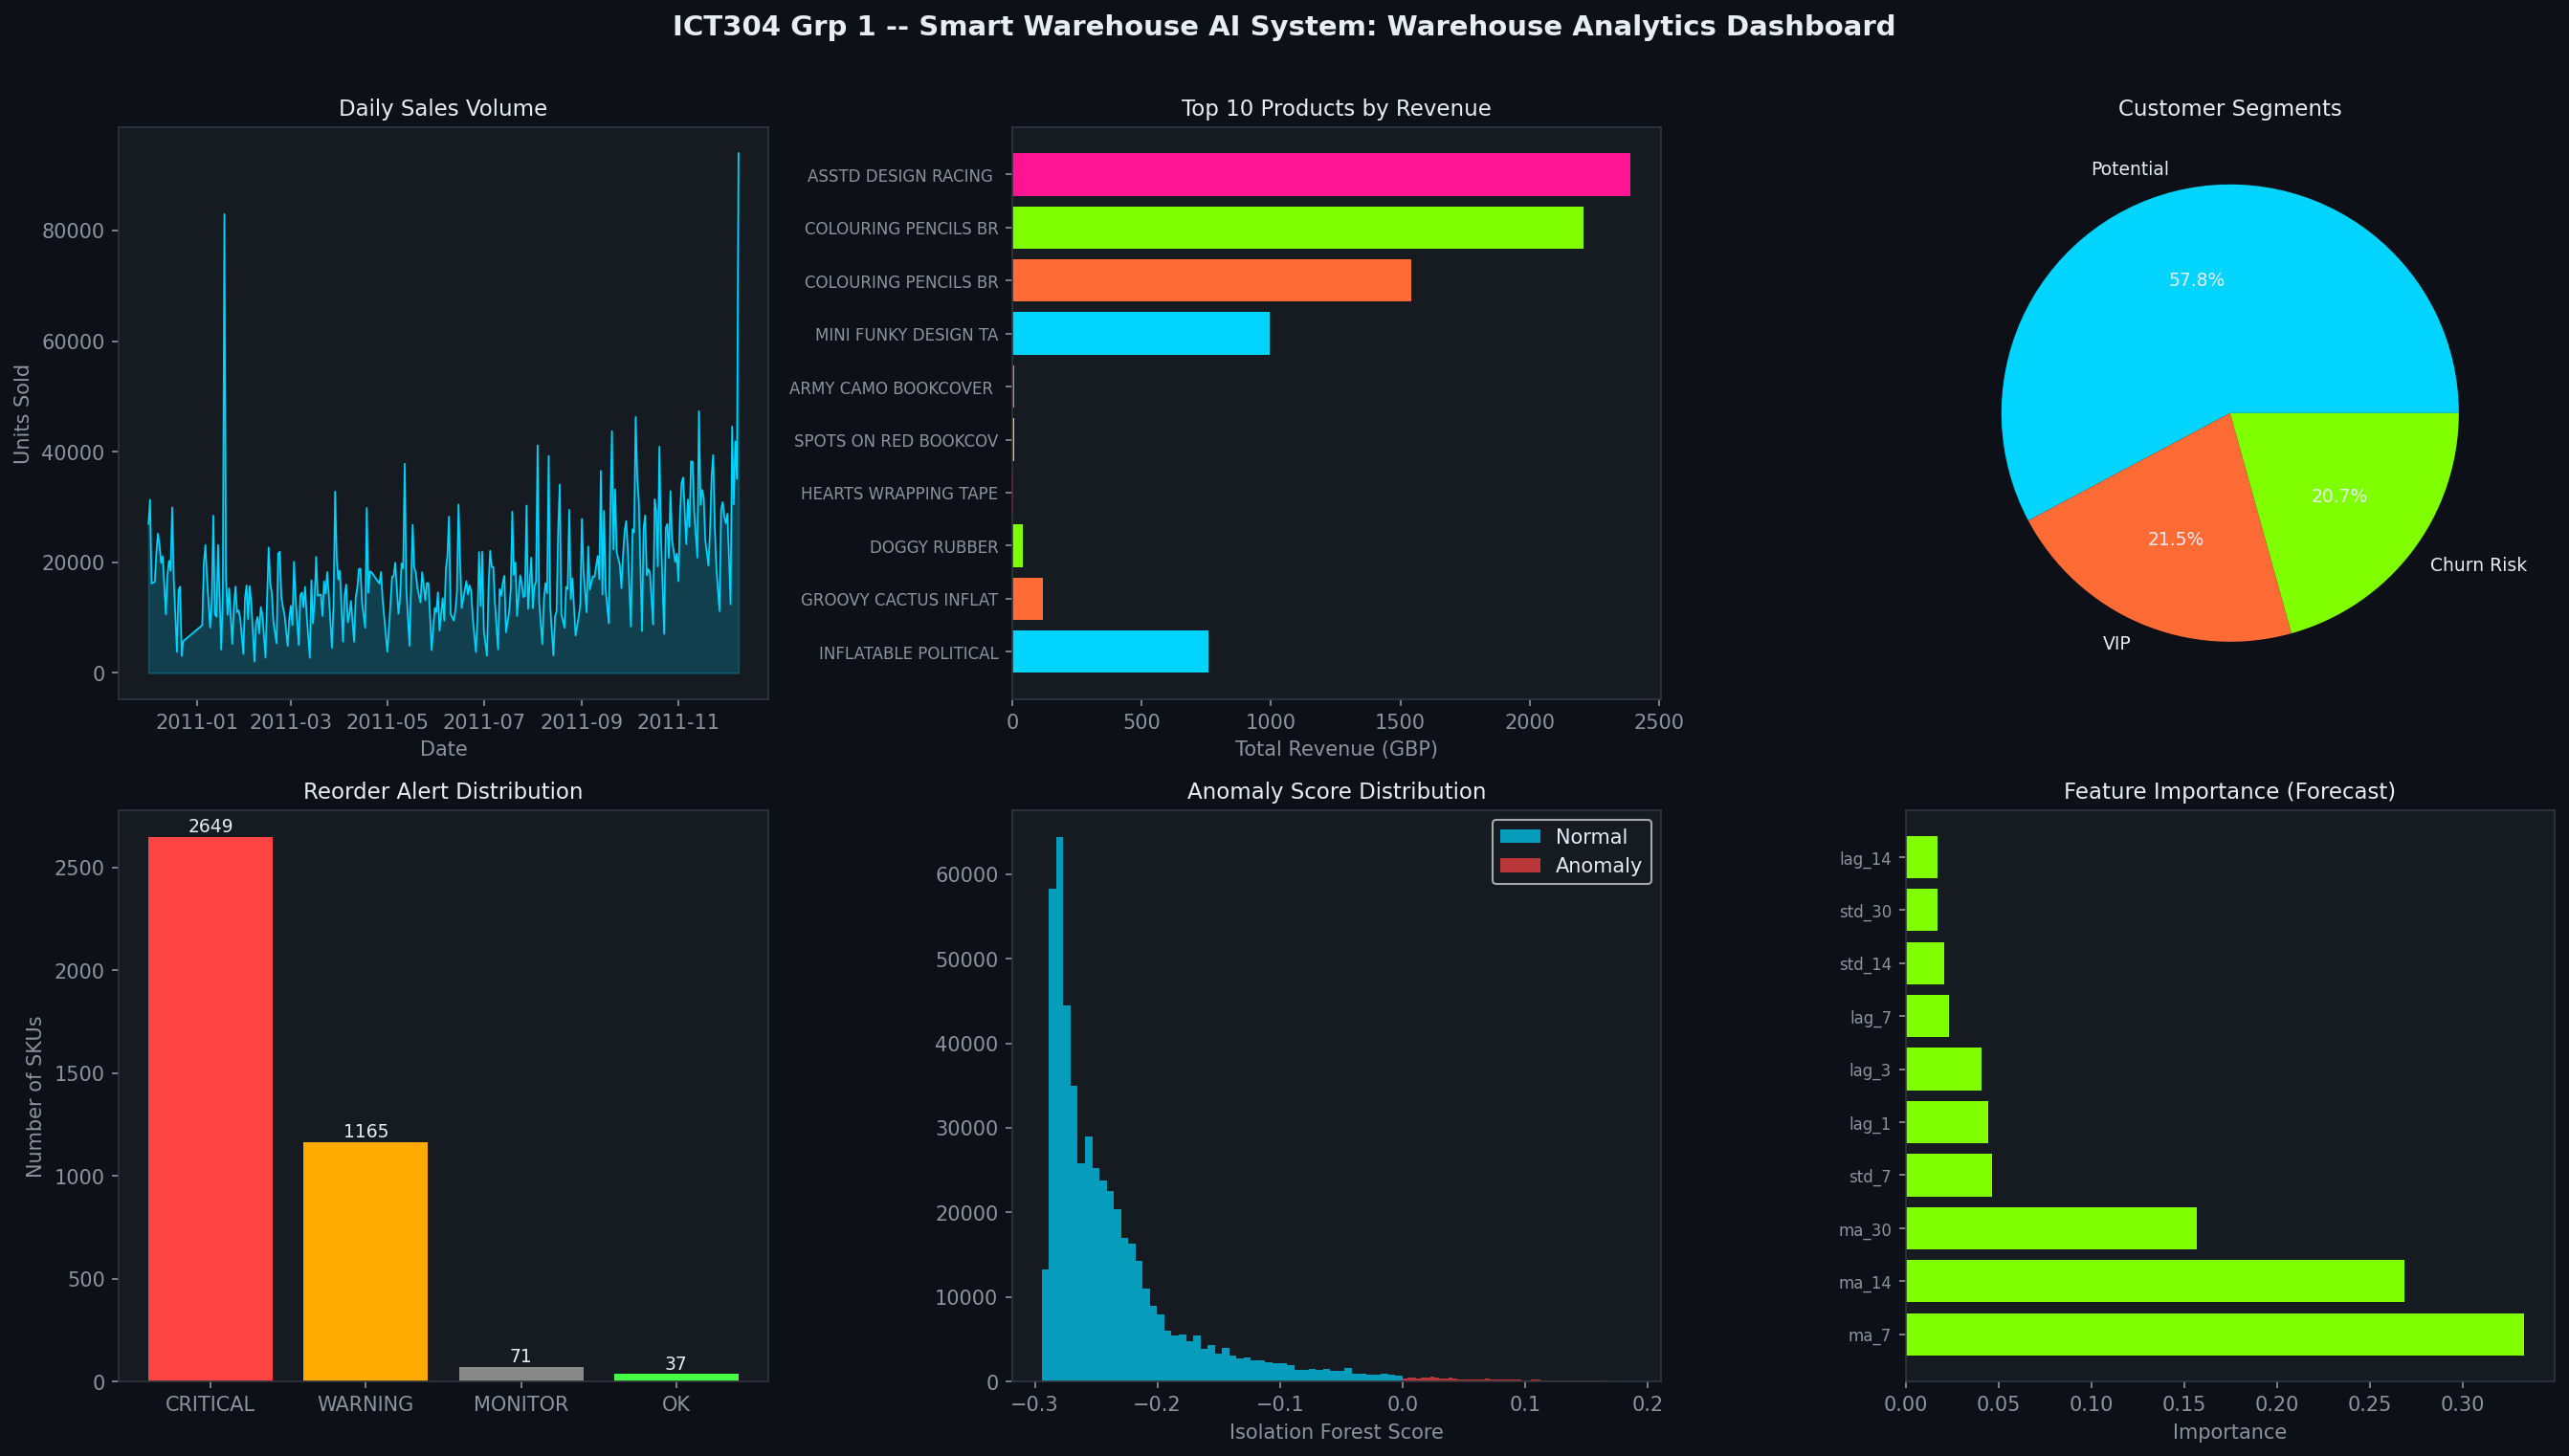


✅ Smart Warehouse Analytics Dashboard complete.


In [ ]:
%matplotlib inline

COLORS = ['#00d4ff','#ff6b35','#7fff00','#ff1493','#ffd700','#da70d6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes.flat:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# Chart 1 -- Daily Sales Trend
ax = axes[0, 0]
daily_total = daily.groupby('Date')['DailyQty'].sum()
ax.plot(daily_total.index, daily_total.values, color='#00d4ff', linewidth=0.8)
ax.fill_between(daily_total.index, daily_total.values, alpha=0.2, color='#00d4ff')
ax.set_title('Daily Sales Volume', color='#e6edf3', fontsize=11)
ax.set_xlabel('Date', color='#8b949e')
ax.set_ylabel('Units Sold', color='#8b949e')

# Chart 2 -- Top 10 Products by Revenue
ax = axes[0, 1]
top10 = inv.head(10)
bars = ax.barh(range(len(top10)), top10['TotalRevenue'],
               color=[COLORS[i % len(COLORS)] for i in range(len(top10))])
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([s[:20] for s in top10['Description']], color='#8b949e', fontsize=8)
ax.set_title('Top 10 Products by Revenue', color='#e6edf3', fontsize=11)
ax.set_xlabel('Total Revenue (GBP)', color='#8b949e')

# Chart 3 -- Customer Segments Pie
ax = axes[0, 2]
seg_counts = rfm['SegmentName'].value_counts()
ax.pie(seg_counts.values, labels=seg_counts.index,
       colors=COLORS[:len(seg_counts)], autopct='%1.1f%%',
       textprops={'color': '#e6edf3', 'fontsize': 9})
ax.set_title('Customer Segments', color='#e6edf3', fontsize=11)

# Chart 4 -- Alert Level Distribution
ax = axes[1, 0]
alert_dist = alerts['AlertLevel'].value_counts()
alert_colors = {'CRITICAL': '#ff4444', 'WARNING': '#ffaa00', 'OK': '#44ff44'}
bars = ax.bar(alert_dist.index,
              alert_dist.values,
              color=[alert_colors.get(k, '#888') for k in alert_dist.index])
ax.set_title('Reorder Alert Distribution', color='#e6edf3', fontsize=11)
ax.set_ylabel('Number of SKUs', color='#8b949e')
for bar, val in zip(bars, alert_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', color='#e6edf3', fontsize=9)

# Chart 5 -- Anomaly Score Distribution
ax = axes[1, 1]
normal  = anom_df[anom_df['IsAnomaly_IF'] == 0]['AnomalyScore']
anomaly = anom_df[anom_df['IsAnomaly_IF'] == 1]['AnomalyScore']
ax.hist(normal,  bins=50, alpha=0.7, color='#00d4ff', label='Normal')
ax.hist(anomaly, bins=50, alpha=0.7, color='#ff4444', label='Anomaly')
ax.set_title('Anomaly Score Distribution', color='#e6edf3', fontsize=11)
ax.set_xlabel('Isolation Forest Score', color='#8b949e')
ax.legend(facecolor='#161b22', labelcolor='#e6edf3')

# Chart 6 -- Feature Importance
ax = axes[1, 2]
fi_top = pd.Series(rf_model.feature_importances_,
                    index=rf_model.feature_names_in_).nlargest(10)
bars = ax.barh(range(len(fi_top)), fi_top.values, color='#7fff00')
ax.set_yticks(range(len(fi_top)))
ax.set_yticklabels(fi_top.index, color='#8b949e', fontsize=8)
ax.set_title('Feature Importance (Forecast)', color='#e6edf3', fontsize=11)
ax.set_xlabel('Importance', color='#8b949e')

plt.suptitle('ICT304 Grp 1 -- Smart Warehouse AI System: Warehouse Analytics Dashboard',
             color='#e6edf3', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/smartWH_analytics_dashboard.png', facecolor=FBG, dpi=100, bbox_inches='tight')
plt.show()
print('\n✅ Smart Warehouse Analytics Dashboard complete.')

---
## Cell 10 -- Interactive Forecast Explorer (Widget)

Select any SKU from the top 50 and adjust the forecast horizon to see the
predicted demand for the coming days.


In [ ]:
# Redefine explicitly to avoid stale variable from kernel
feature_cols = (
    [f'lag_{l}' for l in LAGS] +
    [f'ma_{w}'  for w in WINDOWS] +
    [f'std_{w}' for w in WINDOWS] +
    ['dow', 'month']
)
print('feature_cols reset:', feature_cols)

if WIDGETS_OK:
    print('\nLoading interactive widgets...\n')

    # Forecast explorer
    forecast_sku_input = widgets.Dropdown(options=daily['StockCode'].unique()[:100].tolist(), description='SKU:')
    forecast_horizon = widgets.IntSlider(value=14, min=1, max=30, description='Horizon:')
    forecast_output = widgets.Output()

    def update_forecast(sku, horizon):
        with forecast_output:
            clear_output(wait=True)
            sku_hist = daily[daily['StockCode'] == sku].tail(60)
            if len(sku_hist) > 0:
                forecast_df = forecast_sku(rf_model, feature_cols, daily, sku, horizon)
                fig, ax = plt.subplots(figsize=(10, 4), facecolor=FBG)
                ax.plot(range(len(sku_hist)), sku_hist['DailyQty'].values,
                        'o-', color=COLORS[0], label='Historical')
                ax.plot(range(len(sku_hist), len(sku_hist) + len(forecast_df)),
                        forecast_df['forecast'].values, 's--', color=COLORS[1], label='Forecast')
                ax.legend(facecolor=ABG, edgecolor=TC)
                ax.set_title(f'SKU {sku}', color=TC)
                ax.tick_params(colors=MC)
                for spine in ax.spines.values():
                    spine.set_color(MC)
                plt.tight_layout()
                plt.show()

    controls = widgets.VBox([forecast_sku_input, forecast_horizon])
    print('Forecast Explorer:')
    display(widgets.VBox([controls, forecast_output]))
    update_forecast(forecast_sku_input.value, forecast_horizon.value)  # trigger initial plot
    forecast_sku_input.observe(lambda c: update_forecast(c['new'], forecast_horizon.value), names='value')
    forecast_horizon.observe(lambda c: update_forecast(forecast_sku_input.value, c['new']), names='value')

    # Alert filter
    # Filter reorder alerts by severity level and see the top items requiring attention.
    alert_level_toggle = widgets.ToggleButtons(options=['CRITICAL', 'WARNING', 'MONITOR', 'OK'], description='Level:')
    alert_topn = widgets.IntSlider(value=5, min=1, max=50, description='Top N:')
    alert_output = widgets.Output()

    def update_alerts(level, topn):
        with alert_output:
            clear_output()
            filtered = alerts[alerts['AlertLevel'] == level].nlargest(topn, 'FuzzyPriority')
            print(filtered[['StockCode','Description','Coverage','DemandCV','FuzzyPriority','AlertLevel']].to_string())

    interactive_alerts = widgets.interactive(update_alerts, level=alert_level_toggle, topn=alert_topn)
    print('\nAlert Filter:')
    display(interactive_alerts)
    display(alert_output)

    # Customer Segment explorer
    # Explore each customer segment: see their RFM profile and top purchased products.
    segment_dropdown = widgets.Dropdown(options=rfm['SegmentName'].unique().tolist(), description='Segment:')
    segment_output = widgets.Output()

    def update_segment(segment):
        with segment_output:
            clear_output()
            seg_data = rfm[rfm['SegmentName'] == segment]
            print(f'Segment: {segment}')
            print(f'Count: {len(seg_data):,}')
            print(f'Avg Recency: {seg_data["Recency"].mean():.1f} days')
            print(f'Avg Frequency: {seg_data["Frequency"].mean():.1f} purchases')
            print(f'Avg Monetary: £{seg_data["Monetary"].mean():.2f}')

    interactive_segment = widgets.interactive(update_segment, segment=segment_dropdown)
    print('\nSegment Explorer:')
    display(interactive_segment)
    display(segment_output)
else:
    print('Widgets not available in this environment. Install with: !pip install ipywidgets')

# Show initial outputs first until widgets are selected
update_alerts(alert_level_toggle.value, alert_topn.value)
update_segment(segment_dropdown.value)

feature_cols reset: ['lag_1', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'ma_7', 'ma_14', 'ma_30', 'std_7', 'std_14', 'std_30', 'dow', 'month']

Loading interactive widgets...

Forecast Explorer:



Alert Filter:


interactive(children=(ToggleButtons(description='Level:', options=('CRITICAL', 'WARNING', 'MONITOR', 'OK'), va…

Output()


Segment Explorer:


interactive(children=(Dropdown(description='Segment:', options=('Churn Risk', 'VIP', 'Potential'), value='Chur…

Output()

---
## Cell 11 -- System Summary & Exports

Final summary of all pipeline outputs and download links for key results.


In [ ]:
# =====================================================
#  Export & Download -- All Visualisations + CSV Files
# =====================================================

print('=' * 60)
print(' ' * 9 +'Smart Warehouse AI System -- Final Summary')
print('=' * 60)
print()

print('[Subsystem 1] Data Ingestion')
print(f'  Raw records:          {len(df_raw):,}')
print(f'  Clean records:        {len(df_clean):,}')
print(f'  Unique SKUs:          {inv["StockCode"].nunique():,}')
print(f'  Unique customers:     {df_seg["CustomerID"].nunique():,}')
print(f'  Countries:            {df_clean["Country"].nunique()}')
print(f'  Date range:           {df_clean["InvoiceDate"].min().date()} to {df_clean["InvoiceDate"].max().date()}')
print()

print('[Subsystem 2] Demand Forecasting (Random Forest)')
print(f'  Top SKUs modeled:     {len(train_set["StockCode"].unique())}')
print(f'  Lags/windows:         [1,3,7,14,21] + [7,14,30]')
print(f'  Train/Val/Test split: {len(train_set):,} / {len(val_set):,} / {len(test_set):,}')
print(f'  Test MAE:             {test_mae:.2f} units')
print(f'  Test RMSE:            {test_rmse:.2f} units')
print(f'  Test R2:              {test_r2:.3f}')
print()

print('[Subsystem 3] Anomaly Detection (Isolation Forest)')
print(f'  Total transactions:   {len(anom_df):,}')
print(f'  IQR flagged:          {anom_df["IsAnomaly_IQR"].sum():,}')
print(f'  IF flagged:           {anom_df["IsAnomaly_IF"].sum():,}')
print(f'  Both methods agree:   {(anom_df["IsAnomaly_IQR"] & anom_df["IsAnomaly_IF"]).sum():,}')
print()

print('[Subsystem 4] Customer Segmentation (K-Means)')
for seg_name in rfm['SegmentName'].unique():
    count = len(rfm[rfm['SegmentName'] == seg_name])
    pct = 100 * count / len(rfm)
    print(f'  {seg_name:<12}: {count:>6,} customers ({pct:>5.1f}%)')
print()

print('[Subsystem 5] Fuzzy Logic Reorder System')
for lvl in ['CRITICAL', 'WARNING', 'MONITOR', 'OK']:
    count = len(alerts[alerts['AlertLevel'] == lvl])
    pct = 100 * count / len(alerts)
    print(f'  {lvl:<10}: {count:>6,} SKUs ({pct:>5.1f}%)')
print()
print('=' * 60)

# Export Visualisations and CSV Files
from google.colab import files
import os, zipfile

export_files = [
    ('/tmp/subsystem1_dataIngestion.png',          'Subsystem 1 -- Data Ingestion'),
    ('/tmp/subsystem2_rf_model.png',               'Subsystem 2 -- RF Model Metrics'),
    ('/tmp/subsystem2_forecast.png',               'Subsystem 2 -- SKU Forecast'),
    ('/tmp/subsystem3_anomaly_detection.png',       'Subsystem 3 -- Anomaly Detection'),
    ('/tmp/subsystem4_customer_segmentation.png',   'Subsystem 4 -- Customer Segmentation'),
    ('/tmp/subsystem5_fuzzy_reorder_system.png',    'Subsystem 5 -- Fuzzy Reorder System'),
    ('/tmp/smartWH_analytics_dashboard.png',        'Smart Warehouse Analytics Dashboard'),
    ('/content/smartWH_fuzzy_reorder.csv',          'Subsystem 5 -- Fuzzy Reorder CSV'),
]

ZIP_PATH = '/tmp/smartWH_all_exports.zip'

print('\n Packaging all files into zip...\n')
included, skipped = 0, 0

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path, label in export_files:
        if os.path.isfile(path):
            size_kb = os.path.getsize(path) / 1024
            zf.write(path, os.path.basename(path))   # store with filename only
            print(f'  ✅ {label:<45} ({size_kb:.1f} KB)')
            included += 1
        else:
            print(f'  ⚠️  Missing: {label}  [{path}]')
            skipped += 1

zip_size_kb = os.path.getsize(ZIP_PATH) / 1024
print(f'\n  Included : {included} file(s)')
print(f'  Missing  : {skipped} file(s)')
print(f'  Zip size : {zip_size_kb:.1f} KB')
if skipped > 0:
    print('  → Re-run the missing subsystem cell then run this cell again.')

print('\n Downloading zip...')
files.download(ZIP_PATH)
print(' ✅ Download triggered: smartWH_all_exports.zip')



# Download data files (Un-comment below codes if need to download)
# Export CSV Files
print('Exporting data files...')
try:
    df_clean[['StockCode', 'Description', 'Quantity', 'UnitPrice', 'TotalRevenue', 'CustomerID', 'Country', 'InvoiceDate']].to_csv('/tmp/smartWH_clean_data.csv', index=False)
    print('  smartWH_clean_data.csv')
    rfm.to_csv('/tmp/smartWH_customer_segments.csv', index=False)
    print('  smartWH_customer_segments.csv')
    anom_df[['StockCode', 'Quantity', 'UnitPrice', 'TotalRevenue', 'IsAnomaly_IQR', 'IsAnomaly_IF', 'AnomalyScore']].to_csv('/tmp/smartWH_anomalies.csv', index=False)
    print('  smartWH_anomalies.csv')
    alerts[['StockCode', 'Description', 'Coverage', 'DemandCV', 'FuzzyPriority', 'AlertLevel', 'ROP', 'EOQ']].to_csv('/tmp/smartWH_fuzzy_alerts.csv', index=False)
    print('  smartWH_fuzzy_alerts.csv')
    print()
    print('✅ All exports complete!')
except Exception as e:
    print(f'⚠️ Export error: {e}')

try:
    from google.colab import files
    print('\nDownloading files from Colab...')
    for fname in ['smartWH_clean_data.csv', 'smartWH_customer_segments.csv', 'smartWH_anomalies.csv', 'smartWH_fuzzy_alerts.csv']:
        files.download(f'/tmp/{fname}')
except ImportError:
    print('️️⚠️ (Not in Google Colab - files available in /tmp/)')

         Smart Warehouse AI System -- Final Summary

[Subsystem 1] Data Ingestion
  Raw records:          541,909
  Clean records:        530,104
  Unique SKUs:          3,922
  Unique customers:     4,338
  Countries:            38
  Date range:           2010-12-01 to 2011-12-09

[Subsystem 2] Demand Forecasting (Random Forest)
  Top SKUs modeled:     34
  Lags/windows:         [1,3,7,14,21] + [7,14,30]
  Train/Val/Test split: 8,161 / 1,749 / 1,749
  Test MAE:             53.36 units
  Test RMSE:            129.51 units
  Test R2:              0.143

[Subsystem 3] Anomaly Detection (Isolation Forest)
  Total transactions:   530,104
  IQR flagged:          105,738
  IF flagged:           10,573
  Both methods agree:   10,568

[Subsystem 4] Customer Segmentation (K-Means)
  Churn Risk  :    897 customers ( 20.7%)
  VIP         :    934 customers ( 21.5%)
  Potential   :  2,507 customers ( 57.8%)

[Subsystem 5] Fuzzy Logic Reorder System
  CRITICAL  :  2,649 SKUs ( 67.5%)
  MONITOR   : 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 ✅ Download triggered: smartWH_all_exports.zip
Exporting data files...
  smartWH_clean_data.csv
  smartWH_customer_segments.csv
  smartWH_anomalies.csv
  smartWH_fuzzy_alerts.csv

✅ All exports complete!



<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Smart Warehouse Browser-Based Dashboard



In [ ]:
!pip install -q gradio

import gradio as gr

def run_forecast(sku, horizon):
    try:
        # Check SKU exists in daily
        sku_hist = daily[daily['StockCode'] == sku].sort_values('Date').tail(60)
        if len(sku_hist) == 0:
            fig, ax = plt.subplots(figsize=(10, 4), facecolor=FBG)
            ax.text(0.5, 0.5, f'No data found for SKU {sku}',
                    ha='center', va='center', color=TC, fontsize=14,
                    transform=ax.transAxes)
            return fig

        forecast_df = forecast_sku(rf_model, feature_cols, daily, sku, int(horizon))

        plt.close('all')   # close any previous figures
        fig, ax = plt.subplots(figsize=(10, 4), facecolor=FBG)
        ax.set_facecolor(ABG)

        hist_x   = range(len(sku_hist))
        future_x = range(len(sku_hist), len(sku_hist) + len(forecast_df))

        ax.plot(hist_x, sku_hist['DailyQty'].values,
                'o-', color=COLORS[0], linewidth=2, label='Historical')
        ax.plot(future_x, forecast_df['forecast'].values,
                's--', color=COLORS[1], linewidth=2, label='Forecast')
        ax.fill_between(future_x, forecast_df['forecast'].values,
                        alpha=0.2, color=COLORS[1])
        ax.axvline(x=len(sku_hist), color=MC, linestyle=':', linewidth=1)
        ax.set_xlabel('Days', color=MC)
        ax.set_ylabel('Daily Quantity', color=MC)
        ax.set_title(f'SKU {sku} — Last {len(sku_hist)} Days + {int(horizon)}-Day Forecast',
                     color=TC, fontweight='bold')
        ax.legend(facecolor=ABG, edgecolor=TC)
        ax.tick_params(colors=MC)
        for spine in ax.spines.values():
            spine.set_color(MC)
        plt.tight_layout()
        return fig

    except Exception as e:
        plt.close('all')
        fig, ax = plt.subplots(figsize=(10, 4), facecolor=FBG)
        ax.text(0.5, 0.5, f'Error: {str(e)}',
                ha='center', va='center', color='red', fontsize=12,
                transform=ax.transAxes, wrap=True)
        return fig

def run_alerts(level, top_n):
    filtered = alerts[alerts['AlertLevel'] == level].nlargest(int(top_n), 'FuzzyPriority')
    return filtered[['StockCode','Description','Coverage','DemandCV',
                      'FuzzyPriority','AlertLevel']].reset_index(drop=True)

def run_segment(segment):
    seg = rfm[rfm['SegmentName'] == segment]
    return (f"Segment : {segment}\n"
            f"Count   : {len(seg):,}\n"
            f"Avg Recency   : {seg['Recency'].mean():.1f} days\n"
            f"Avg Frequency : {seg['Frequency'].mean():.1f} purchases\n"
            f"Avg Monetary  : £{seg['Monetary'].mean():.2f}")

sku_list = (daily.groupby('StockCode').filter(lambda x: len(x) > 5)['StockCode'].unique()[:100].tolist())
segment_list = rfm['SegmentName'].unique().tolist()

with gr.Blocks(title='SmartWH Dashboard') as demo:
    gr.Markdown("# Smart Warehouse AI System")

    with gr.Tab("Forecast Explorer"):
        sku_dd  = gr.Dropdown(choices=sku_list, label='SKU', value=sku_list[0])
        horizon = gr.Slider(1, 30, value=14, label='Forecast Horizon (days)')
        plot    = gr.Plot()
        btn1    = gr.Button("Run Forecast")
        btn1.click(run_forecast, inputs=[sku_dd, horizon], outputs=plot)

    with gr.Tab("Alert Filter"):
        level  = gr.Radio(['CRITICAL','WARNING','MONITOR','OK'],
                          value='CRITICAL', label='Alert Level')
        top_n  = gr.Slider(1, 50, value=5, step=1, label='Top N')
        table  = gr.Dataframe()
        btn2   = gr.Button("Filter Alerts")
        btn2.click(run_alerts, inputs=[level, top_n], outputs=table)

    with gr.Tab("Segment Explorer"):
        seg_dd = gr.Dropdown(choices=segment_list, label='Segment',
                             value=segment_list[0])
        stats  = gr.Textbox(label='Segment Stats', lines=6)
        btn3   = gr.Button("View Segment")
        btn3.click(run_segment, inputs=seg_dd, outputs=stats)

demo.launch(share=True, debug=False)   # share=True gives a public link valid for 72 hours

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc7600bfe79cb1c2be.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Streamlit GUI

In [ ]:
# Install dependencies
!pip install -q streamlit pyngrok openpyxl scikit-fuzzy scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 118.4 MB/s eta 0:00:00


In [ ]:
# Write the Streamlit app
%%writefile smartwh_app.py

import streamlit as st
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings, math
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from scipy.interpolate import RegularGridInterpolator
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ── Constants ────────────────────────────────────────────────
COLORS = ['#00d4ff','#ff6b35','#7fff00','#ff1493','#ffd700','#da70d6','#87ceeb','#98fb98']
FBG = '#0d1117'; ABG = '#161b22'; TC = '#e6edf3'; MC = '#8b949e'
LAGS = [1, 3, 7, 14, 21]
WINDOWS = [7, 14, 30]
FORECAST_HORIZON = 14
LEAD_TIME = 7
plt.style.use('dark_background')

# ── Page config ───────────────────────────────────────────────
st.set_page_config(
    page_title='SmartWH AI System',
    page_icon='🏭',
    layout='wide',
    initial_sidebar_state='expanded'
)

st.markdown("""
<style>
    .stApp { background-color: #0d1117; color: #e6edf3; }
    section[data-testid="stSidebar"] { background-color: #161b22; }
    .stMetric { background-color: #161b22; border-radius: 8px; padding: 8px; }
</style>
""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════
# SUBSYSTEM FUNCTIONS
# ══════════════════════════════════════════════════════════════

def clean_data(df):
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
    if df['Description'].isna().any():
        mode_desc = df.groupby('StockCode')['Description'].agg(
            lambda x: x.mode()[0] if len(x.mode()) > 0 else 'UNKNOWN')
        df['Description'] = df.apply(
            lambda r: mode_desc.get(r['StockCode'], 'UNKNOWN')
            if pd.isna(r['Description']) else r['Description'], axis=1)
    df['HasCustomerID'] = ~df['CustomerID'].isna()
    df['CustomerID']    = df['CustomerID'].fillna('ANON')
    return df

def engineer_features(df):
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
    df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
    df['Date']      = df['InvoiceDate'].dt.date
    df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
    df['Month']     = df['InvoiceDate'].dt.month
    df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)
    return df

def build_daily_demand(df):
    daily = df.groupby(['Date','StockCode']).agg(
        {'Quantity':'sum','UnitPrice':'mean','TotalRevenue':'sum','Description':'first'}
    ).reset_index()
    daily.columns = ['Date','StockCode','DailyQty','AvgPrice','DailyRevenue','Description']
    daily['Date'] = pd.to_datetime(daily['Date'])
    return daily.sort_values('Date').reset_index(drop=True)

def build_inventory_summary(df):
    inv = df.groupby('StockCode').agg({
        'Quantity':'sum','UnitPrice':'mean','TotalRevenue':'sum',
        'Description':'first',
        'Country': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
    }).reset_index()
    inv.columns = ['StockCode','TotalQty','AvgUnitPrice','TotalRevenue','Description','TopCountry']
    return inv

def create_lag_features(ts):
    df = ts.copy()
    for lag in LAGS:
        df[f'lag_{lag}'] = df['DailyQty'].shift(lag)
    for win in WINDOWS:
        df[f'ma_{win}']  = df['DailyQty'].rolling(win, min_periods=1).mean()
        df[f'std_{win}'] = df['DailyQty'].rolling(win, min_periods=1).std().fillna(0)
    df['dow']   = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    return df.bfill()

def build_training_data(daily_ts, top_n=50):
    top_skus = daily_ts.groupby('StockCode')['DailyQty'].sum().nlargest(top_n).index.tolist()
    subset = daily_ts[daily_ts['StockCode'].isin(top_skus)].copy()
    parts  = []
    for sku in top_skus:
        sku_ts = subset[subset['StockCode'] == sku].sort_values('Date').reset_index(drop=True)
        parts.append(create_lag_features(sku_ts))
    return pd.concat(parts, ignore_index=True)

def chronological_split(df, train=0.70, val=0.15):
    n = len(df)
    return df[:int(n*train)], df[int(n*train):int(n*(train+val))], df[int(n*(train+val)):]

def forecast_sku(model, feature_cols, daily_df, sku, horizon=FORECAST_HORIZON):
    s = daily_df[daily_df['StockCode'] == sku].set_index('Date')['DailyQty'].sort_index()
    if len(s) == 0:
        return pd.DataFrame({'date':[], 'forecast':[]})
    history_values = list(s.values)
    last_date = s.index[-1]
    preds, dates = [], []
    for step in range(horizon):
        fut_date = last_date + pd.Timedelta(days=step+1)
        row = {}
        for lag in LAGS:
            idx = len(history_values) - lag
            row[f'lag_{lag}'] = history_values[idx] if idx >= 0 else 0
        for win in WINDOWS:
            recent = history_values[-win:]
            row[f'ma_{win}']  = float(np.mean(recent)) if recent else 0.0
            row[f'std_{win}'] = float(np.std(recent))  if len(recent) > 1 else 0.0
        row['dow']   = fut_date.dayofweek
        row['month'] = fut_date.month
        X_row = np.array([[row[c] for c in feature_cols]])
        pred  = float(np.maximum(0, model.predict(X_row))[0])
        preds.append(pred); dates.append(fut_date)
        history_values.append(pred)
    return pd.DataFrame({'date': dates, 'forecast': preds})

def build_fuzzy_system():
    cov_u = np.arange(0, 5.05, 0.05)
    vol_u = np.arange(0, 3.05, 0.05)
    pri_u = np.arange(0, 101, 1)
    cov = ctrl.Antecedent(cov_u, 'coverage')
    vol = ctrl.Antecedent(vol_u, 'volatility')
    pri = ctrl.Consequent(pri_u, 'priority')
    cov['critical'] = fuzz.trapmf(cov.universe, [0,0,0.5,1.0])
    cov['low']      = fuzz.trimf(cov.universe,  [0.5,1.5,2.5])
    cov['adequate'] = fuzz.trimf(cov.universe,  [2.0,3.0,4.0])
    cov['high']     = fuzz.trapmf(cov.universe, [3.5,4.5,5,5])
    vol['stable']   = fuzz.trapmf(vol.universe, [0,0,0.3,0.6])
    vol['variable'] = fuzz.trimf(vol.universe,  [0.4,1.0,1.8])
    vol['volatile'] = fuzz.trapmf(vol.universe, [1.5,2.5,3,3])
    pri['none']     = fuzz.trapmf(pri.universe, [0,0,10,20])
    pri['low']      = fuzz.trimf(pri.universe,  [15,30,45])
    pri['medium']   = fuzz.trimf(pri.universe,  [35,50,65])
    pri['high']     = fuzz.trimf(pri.universe,  [55,70,85])
    pri['critical'] = fuzz.trapmf(pri.universe, [75,90,100,100])
    rules = [
        ctrl.Rule(cov['critical'],                       pri['critical']),
        ctrl.Rule(cov['low']      & vol['volatile'],     pri['critical']),
        ctrl.Rule(cov['low']      & vol['variable'],     pri['high']),
        ctrl.Rule(cov['low']      & vol['stable'],       pri['medium']),
        ctrl.Rule(cov['adequate'] & vol['volatile'],     pri['high']),
        ctrl.Rule(cov['adequate'] & vol['variable'],     pri['medium']),
        ctrl.Rule(cov['adequate'] & vol['stable'],       pri['low']),
        ctrl.Rule(cov['high']     & vol['volatile'],     pri['low']),
        ctrl.Rule(cov['high']     & vol['variable'],     pri['none']),
        ctrl.Rule(cov['high']     & vol['stable'],       pri['none']),
    ]
    system = ctrl.ControlSystem(rules)
    cov_pts = np.arange(0, 5.1, 0.1)
    vol_pts = np.arange(0, 3.1, 0.1)
    grid    = np.zeros((len(cov_pts), len(vol_pts)))
    sim     = ctrl.ControlSystemSimulation(system)
    for i, c in enumerate(cov_pts):
        for j, v in enumerate(vol_pts):
            try:
                sim.input['coverage']   = float(c)
                sim.input['volatility'] = float(v)
                sim.compute()
                grid[i,j] = sim.output['priority']
            except:
                grid[i,j] = 50.0
    interp = RegularGridInterpolator((cov_pts, vol_pts), grid,
                                     method='linear', bounds_error=False, fill_value=None)
    return interp

# ══════════════════════════════════════════════════════════════
# CACHED DATA LOADERS
# ══════════════════════════════════════════════════════════════

@st.cache_data(show_spinner=False)
def load_data(file_bytes):
    df_raw   = pd.read_excel(file_bytes, dtype={'InvoiceNo':str,'StockCode':str})
    df_clean = engineer_features(clean_data(df_raw))
    daily    = build_daily_demand(df_clean)
    inv      = build_inventory_summary(df_clean)
    df_seg   = df_clean[df_clean['HasCustomerID']].copy()
    return df_raw, df_clean, daily, inv, df_seg

@st.cache_resource(show_spinner=False)
def train_rf(_daily):
    df_train = build_training_data(_daily)
    feature_cols = (
        [f'lag_{l}' for l in LAGS] +
        [f'ma_{w}'  for w in WINDOWS] +
        [f'std_{w}' for w in WINDOWS] +
        ['dow', 'month']
    )
    train_set, val_set, test_set = chronological_split(df_train.dropna())
    model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(train_set[feature_cols], train_set['DailyQty'])
    y_pred = model.predict(test_set[feature_cols])
    metrics = {
        'mae':  mean_absolute_error(test_set['DailyQty'], y_pred),
        'rmse': np.sqrt(mean_squared_error(test_set['DailyQty'], y_pred)),
        'r2':   r2_score(test_set['DailyQty'], y_pred),
        'train': len(train_set), 'val': len(val_set), 'test': len(test_set),
    }
    return model, feature_cols, metrics

@st.cache_resource(show_spinner=False)
def compute_rfm(_df_seg):
    ref  = _df_seg['InvoiceDate'].max() + pd.Timedelta(days=1)
    rfm  = _df_seg.groupby('CustomerID').agg({
        'InvoiceDate':  lambda x: (ref - x.max()).days,
        'InvoiceNo':    'count',
        'TotalRevenue': 'sum'
    }).reset_index()
    rfm.columns = ['CustomerID','Recency','Frequency','Monetary']
    rfm['Monetary']      = rfm['Monetary'].round(2)
    rfm['log_Frequency'] = np.log1p(rfm['Frequency'])
    rfm['log_Monetary']  = np.log1p(rfm['Monetary'])
    scaled = RobustScaler().fit_transform(rfm[['Recency','log_Frequency','log_Monetary']])
    rfm['Segment'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(scaled)
    stats = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
    names = {}
    for seg in stats.index:
        r, f, m = stats.loc[seg,'Recency'], stats.loc[seg,'Frequency'], stats.loc[seg,'Monetary']
        if m > rfm['Monetary'].quantile(0.75) and f > rfm['Frequency'].quantile(0.75):
            names[seg] = 'VIP'
        elif r <= rfm['Recency'].quantile(0.33) and f >= rfm['Frequency'].quantile(0.50):
            names[seg] = 'Active'
        elif r >= rfm['Recency'].quantile(0.66):
            names[seg] = 'Churn Risk'
        else:
            names[seg] = 'Potential'
    rfm['SegmentName'] = rfm['Segment'].map(names)
    return rfm

@st.cache_resource(show_spinner=False)
def compute_anomalies(_df_clean):
    a = _df_clean.copy()
    a['QtyZScore_SKU']   = a.groupby('StockCode')['Quantity'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6))
    a['PriceZScore_SKU'] = a.groupby('StockCode')['UnitPrice'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6))
    feats = ['Quantity','UnitPrice','TotalRevenue','QtyZScore_SKU','PriceZScore_SKU']
    X     = a[feats].fillna(0)
    iso   = IsolationForest(contamination=0.02, random_state=42)
    iso.fit(X)
    a['AnomalyScore']  = -iso.decision_function(X)
    a['IsAnomaly_IF']  = (iso.predict(X) == -1).astype(int)
    flags = []
    for col in ['Quantity','UnitPrice','TotalRevenue']:
        Q1, Q3 = a[col].quantile(0.25), a[col].quantile(0.75)
        IQR = Q3 - Q1
        flags.append(((a[col] < Q1-1.5*IQR) | (a[col] > Q3+1.5*IQR)).astype(int))
    a['IsAnomaly_IQR'] = (sum(flags) > 0).astype(int)
    return a[['InvoiceNo','StockCode','Quantity','UnitPrice','TotalRevenue',
               'QtyZScore_SKU','PriceZScore_SKU','AnomalyScore',
               'IsAnomaly_IF','IsAnomaly_IQR','InvoiceDate']]

@st.cache_resource(show_spinner=False)
def compute_alerts(_daily, _inv):
    interp_fn = build_fuzzy_system()
    sku_dem   = _daily.groupby('StockCode')['DailyQty'].agg(Avg='mean', Std='std').fillna(0).reset_index()
    p = _inv.merge(sku_dem, on='StockCode', how='left').fillna(0)
    p['EstCurrentStock'] = p['TotalQty'] * 0.1
    p['Coverage']  = np.where(p['Avg'] > 0, (p['EstCurrentStock'] / (p['Avg'] * LEAD_TIME)).clip(0,5), 5.0)
    p['DemandCV']  = np.where(p['Avg'] > 0.01, (p['Std'] / p['Avg']).clip(0,3), 0.0)
    p['SafetyStock']= (1.645 * p['Std'] * math.sqrt(LEAD_TIME)).round(1)
    p['ROP']       = (p['Avg'] * LEAD_TIME + p['SafetyStock']).round(1)
    ann = p['Avg'] * 365
    hpu = p['AvgUnitPrice'] * 0.25
    p['EOQ'] = np.where(hpu > 0, np.sqrt(2 * ann * 50 / hpu), 0).round(0)
    pts = np.column_stack([p['Coverage'].values.clip(0,5), p['DemandCV'].values.clip(0,3)])
    p['FuzzyPriority'] = interp_fn(pts)
    def lvl(s):
        if s >= 75: return 'CRITICAL'
        if s >= 50: return 'WARNING'
        if s >= 25: return 'MONITOR'
        return 'OK'
    p['AlertLevel'] = p['FuzzyPriority'].apply(lvl)
    return p

# ══════════════════════════════════════════════════════════════
# SIDEBAR
# ══════════════════════════════════════════════════════════════

st.sidebar.markdown("## 🏭 SmartWH AI System")
st.sidebar.markdown("---")

uploaded_file = st.sidebar.file_uploader("📁 Upload Online Retail.xlsx", type=['xlsx'])

st.sidebar.markdown("---")
page = st.sidebar.radio("Navigate", [
    "📊 Dashboard",
    "📈 Forecast Explorer",
    "🚨 Alert Filter",
    "👥 Segment Explorer",
    "🔍 Anomaly Detection",
    "ℹ️ System Info",
])

# ── No file uploaded ─────────────────────────────────────────
if uploaded_file is None:
    st.title("🏭 Smart Warehouse AI System")
    st.info("👈 Upload **Online Retail.xlsx** in the sidebar to begin.")
    st.markdown("""
    ### System Overview
    | Subsystem | Description |
    |-----------|-------------|
    | 📊 Subsystem 1 | Data Ingestion & Validation |
    | 📈 Subsystem 2 | AI Demand Forecasting (Random Forest) |
    | 🔍 Subsystem 3 | Anomaly Detection (Isolation Forest + IQR) |
    | 👥 Subsystem 4 | Customer Segmentation (RFM + K-Means) |
    | 🚨 Subsystem 5 | Fuzzy Logic Reorder System |
    | 📊 Subsystem 6 | Analytics Dashboard |
    """)
    st.stop()

# ── Load and train ────────────────────────────────────────────
with st.spinner("⚙️ Loading data..."):
    df_raw, df_clean, daily, inv, df_seg = load_data(uploaded_file)

with st.spinner("🌲 Training Random Forest..."):
    rf_model, feature_cols, rf_metrics = train_rf(daily)

with st.spinner("👥 Segmenting customers..."):
    rfm = compute_rfm(df_seg)

with st.spinner("🔍 Detecting anomalies..."):
    anom_df = compute_anomalies(df_clean)

with st.spinner("🚨 Computing fuzzy alerts..."):
    alerts = compute_alerts(daily, inv)

st.sidebar.success(f"✅ {len(df_clean):,} records loaded")

# ══════════════════════════════════════════════════════════════
# PAGE: Dashboard
# ══════════════════════════════════════════════════════════════
if page == "📊 Dashboard":
    st.title("📊 Analytics Dashboard")

    c1,c2,c3,c4,c5 = st.columns(5)
    c1.metric("Total SKUs",         f"{inv['StockCode'].nunique():,}")
    c2.metric("Total Customers",    f"{df_seg['CustomerID'].nunique():,}")
    c3.metric("Clean Records",      f"{len(df_clean):,}")
    c4.metric("Critical Alerts",    f"{len(alerts[alerts['AlertLevel']=='CRITICAL']):,}")
    c5.metric("Anomalies (IF)",     f"{int(anom_df['IsAnomaly_IF'].sum()):,}")

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Daily Sales Volume")
        fig, ax = plt.subplots(figsize=(8,3), facecolor=FBG)
        ax.set_facecolor(ABG)
        dt = daily.groupby('Date')['DailyQty'].sum()
        ax.plot(dt.index, dt.values, color=COLORS[0], linewidth=0.8)
        ax.fill_between(dt.index, dt.values, alpha=0.2, color=COLORS[0])
        ax.set_xlabel('Date', color=MC); ax.set_ylabel('Units Sold', color=MC)
        ax.tick_params(colors=MC)
        for s in ax.spines.values(): s.set_color(MC)
        plt.tight_layout(); st.pyplot(fig); plt.close()

    with col2:
        st.subheader("Customer Segments")
        fig, ax = plt.subplots(figsize=(8,3), facecolor=FBG)
        sc = rfm['SegmentName'].value_counts()
        ax.pie(sc.values, labels=sc.index, autopct='%1.1f%%',
               colors=COLORS[:len(sc)], textprops={'color':TC})
        plt.tight_layout(); st.pyplot(fig); plt.close()

    col3, col4 = st.columns(2)

    with col3:
        st.subheader("Alert Distribution")
        fig, ax = plt.subplots(figsize=(8,3), facecolor=FBG)
        ax.set_facecolor(ABG)
        ad = alerts['AlertLevel'].value_counts().reindex(['CRITICAL','WARNING','MONITOR','OK'], fill_value=0)
        ac = {'CRITICAL':'#ff4444','WARNING':'#ffaa00','MONITOR':'#ffd700','OK':'#44ff44'}
        bars = ax.bar(ad.index, ad.values, color=[ac[k] for k in ad.index], alpha=0.85)
        for bar, v in zip(bars, ad.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(v), ha='center', color=TC)
        ax.set_ylabel('SKUs', color=MC); ax.tick_params(colors=MC)
        for s in ax.spines.values(): s.set_color(MC)
        plt.tight_layout(); st.pyplot(fig); plt.close()

    with col4:
        st.subheader("Top 10 Products by Revenue")
        fig, ax = plt.subplots(figsize=(8,3), facecolor=FBG)
        ax.set_facecolor(ABG)
        t10 = inv.nlargest(10,'TotalRevenue')
        ax.barh(range(len(t10)), t10['TotalRevenue'],
                color=[COLORS[i%len(COLORS)] for i in range(len(t10))], alpha=0.85)
        ax.set_yticks(range(len(t10)))
        ax.set_yticklabels([s[:25] for s in t10['Description']], color=MC, fontsize=7)
        ax.set_xlabel('Total Revenue (£)', color=MC); ax.tick_params(colors=MC)
        for s in ax.spines.values(): s.set_color(MC)
        plt.tight_layout(); st.pyplot(fig); plt.close()

# ══════════════════════════════════════════════════════════════
# PAGE: Forecast Explorer
# ══════════════════════════════════════════════════════════════
elif page == "📈 Forecast Explorer":
    st.title("📈 Demand Forecast Explorer")

    sku_list = (daily.groupby('StockCode')
                     .filter(lambda x: len(x) > 5)['StockCode']
                     .unique().tolist())

    col1, col2 = st.columns([3,1])
    with col1:
        selected_sku = st.selectbox("Select SKU", sku_list)
    with col2:
        horizon = st.slider("Horizon (days)", 1, 30, 14)

    if st.button("🔮 Run Forecast", use_container_width=True):
        with st.spinner(f"Forecasting SKU {selected_sku}..."):
            sku_hist    = daily[daily['StockCode'] == selected_sku].sort_values('Date').tail(60)
            forecast_df = forecast_sku(rf_model, feature_cols, daily, selected_sku, horizon)

            fig, ax = plt.subplots(figsize=(12,5), facecolor=FBG)
            ax.set_facecolor(ABG)
            hx = range(len(sku_hist))
            fx = range(len(sku_hist), len(sku_hist)+len(forecast_df))
            ax.plot(hx, sku_hist['DailyQty'].values, 'o-', color=COLORS[0], linewidth=2, label='Historical')
            ax.plot(fx, forecast_df['forecast'].values, 's--', color=COLORS[1], linewidth=2, label='Forecast')
            ax.fill_between(fx, forecast_df['forecast'].values, alpha=0.2, color=COLORS[1])
            ax.axvline(x=len(sku_hist), color=MC, linestyle=':', linewidth=1)
            ax.set_xlabel('Days', color=MC); ax.set_ylabel('Daily Quantity', color=MC)
            ax.set_title(f'SKU {selected_sku} — Last {len(sku_hist)} Days + {horizon}-Day Forecast',
                         color=TC, fontweight='bold')
            ax.legend(facecolor=ABG, edgecolor=MC); ax.tick_params(colors=MC)
            for s in ax.spines.values(): s.set_color(MC)
            plt.tight_layout(); st.pyplot(fig); plt.close()

        st.subheader("Forecast Table")
        st.dataframe(
            forecast_df.rename(columns={'date':'Date','forecast':'Forecast Qty'})
                       .style.format({'Forecast Qty':'{:.1f}'}),
            use_container_width=True)

    st.markdown("---")
    st.subheader("Model Performance")
    c1,c2,c3,c4,c5 = st.columns(5)
    c1.metric("Test MAE",   f"{rf_metrics['mae']:.2f}")
    c2.metric("Test RMSE",  f"{rf_metrics['rmse']:.2f}")
    c3.metric("Test R²",    f"{rf_metrics['r2']:.3f}")
    c4.metric("Train Size", f"{rf_metrics['train']:,}")
    c5.metric("Test Size",  f"{rf_metrics['test']:,}")

# ══════════════════════════════════════════════════════════════
# PAGE: Alert Filter
# ══════════════════════════════════════════════════════════════
elif page == "🚨 Alert Filter":
    st.title("🚨 Fuzzy Logic Reorder Alerts")

    col1, col2 = st.columns([3,1])
    with col1:
        level = st.radio("Alert Level", ['CRITICAL','WARNING','MONITOR','OK'], horizontal=True)
    with col2:
        top_n = st.slider("Top N", 5, 100, 20)

    filtered = alerts[alerts['AlertLevel'] == level].nlargest(top_n, 'FuzzyPriority')
    icons    = {'CRITICAL':'🔴','WARNING':'🟠','MONITOR':'🟡','OK':'🟢'}
    st.markdown(f"### {icons.get(level,'')} {level} — {len(filtered)} SKUs")

    st.dataframe(
        filtered[['StockCode','Description','Coverage','DemandCV',
                  'SafetyStock','ROP','EOQ','FuzzyPriority','AlertLevel']]
                .reset_index(drop=True)
                .style.format({'Coverage':'{:.2f}','DemandCV':'{:.2f}',
                               'FuzzyPriority':'{:.1f}','ROP':'{:.1f}','EOQ':'{:.0f}'}),
        use_container_width=True)

    csv = filtered.to_csv(index=False).encode('utf-8')
    st.download_button("⬇️ Download Filtered Alerts CSV", csv,
                       f"alerts_{level}.csv", "text/csv")

# ══════════════════════════════════════════════════════════════
# PAGE: Segment Explorer
# ══════════════════════════════════════════════════════════════
elif page == "👥 Segment Explorer":
    st.title("👥 Customer Segment Explorer")

    seg_list     = sorted(rfm['SegmentName'].dropna().unique().tolist())
    selected_seg = st.selectbox("Select Segment", seg_list)
    seg_data     = rfm[rfm['SegmentName'] == selected_seg]

    c1,c2,c3,c4 = st.columns(4)
    c1.metric("Customers",     f"{len(seg_data):,}")
    c2.metric("Avg Recency",   f"{seg_data['Recency'].mean():.1f} days")
    c3.metric("Avg Frequency", f"{seg_data['Frequency'].mean():.1f}")
    c4.metric("Avg Monetary",  f"£{seg_data['Monetary'].mean():.2f}")

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Recency vs Monetary")
        fig, ax = plt.subplots(figsize=(7,4), facecolor=FBG)
        ax.set_facecolor(ABG)
        for sn in rfm['SegmentName'].dropna().unique():
            sd = rfm[rfm['SegmentName'] == sn]
            ax.scatter(sd['Recency'], np.log1p(sd['Monetary']),
                       alpha=0.8 if sn==selected_seg else 0.15,
                       s=60 if sn==selected_seg else 15, label=sn)
        ax.set_xlabel('Recency (days)', color=MC)
        ax.set_ylabel('log(Monetary)', color=MC)
        ax.legend(facecolor=ABG, edgecolor=MC); ax.tick_params(colors=MC)
        for s in ax.spines.values(): s.set_color(MC)
        plt.tight_layout(); st.pyplot(fig); plt.close()

    with col2:
        st.subheader("Segment Distribution")
        fig, ax = plt.subplots(figsize=(7,4), facecolor=FBG)
        sc  = rfm['SegmentName'].value_counts()
        exp = [0.08 if s==selected_seg else 0 for s in sc.index]
        ax.pie(sc.values, labels=sc.index, autopct='%1.1f%%',
               colors=COLORS[:len(sc)], explode=exp, textprops={'color':TC})
        plt.tight_layout(); st.pyplot(fig); plt.close()

    st.subheader(f"Top Customers — {selected_seg}")
    st.dataframe(
        seg_data.nlargest(20,'Monetary')[['CustomerID','Recency','Frequency','Monetary']]
                .reset_index(drop=True)
                .style.format({'Monetary':'£{:.2f}','Recency':'{:.0f}','Frequency':'{:.0f}'}),
        use_container_width=True)

# ══════════════════════════════════════════════════════════════
# PAGE: Anomaly Detection
# ══════════════════════════════════════════════════════════════
elif page == "🔍 Anomaly Detection":
    st.title("🔍 Anomaly Detection")

    c1,c2,c3,c4 = st.columns(4)
    c1.metric("Total Transactions", f"{len(anom_df):,}")
    c2.metric("IQR Flagged",        f"{int(anom_df['IsAnomaly_IQR'].sum()):,}")
    c3.metric("IF Flagged",         f"{int(anom_df['IsAnomaly_IF'].sum()):,}")
    c4.metric("Both Agree",         f"{int((anom_df['IsAnomaly_IQR'] & anom_df['IsAnomaly_IF']).sum()):,}")

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Score Distribution")
        fig, ax = plt.subplots(figsize=(7,4), facecolor=FBG)
        ax.set_facecolor(ABG)
        ax.hist(anom_df[anom_df['IsAnomaly_IF']==0]['AnomalyScore'],
                bins=60, alpha=0.7, color=COLORS[0], label='Normal')
        ax.hist(anom_df[anom_df['IsAnomaly_IF']==1]['AnomalyScore'],
                bins=60, alpha=0.7, color='#ff4444', label='Anomaly')
        ax.set_xlabel('Anomaly Score', color=MC)
        ax.legend(facecolor=ABG, labelcolor=TC); ax.tick_params(colors=MC)
        for s in ax.spines.values(): s.set_color(MC)
        plt.tight_layout(); st.pyplot(fig); plt.close()

    with col2:
        st.subheader("Quantity vs Revenue")
        fig, ax = plt.subplots(figsize=(7,4), facecolor=FBG)
        ax.set_facecolor(ABG)
        n = anom_df[anom_df['IsAnomaly_IF']==0]
        a = anom_df[anom_df['IsAnomaly_IF']==1]
        ax.scatter(n['Quantity'], n['TotalRevenue'], alpha=0.2, s=8,  color=COLORS[0], label='Normal')
        ax.scatter(a['Quantity'], a['TotalRevenue'], alpha=0.7, s=30, color='#ff4444', marker='x', label='Anomaly')
        ax.set_xlabel('Quantity', color=MC); ax.set_ylabel('Total Revenue', color=MC)
        ax.legend(facecolor=ABG, labelcolor=TC); ax.tick_params(colors=MC)
        for s in ax.spines.values(): s.set_color(MC)
        plt.tight_layout(); st.pyplot(fig); plt.close()

    st.subheader("Top Anomalies")
    top_anom = anom_df[anom_df['IsAnomaly_IF']==1].nlargest(20,'AnomalyScore')
    st.dataframe(
        top_anom[['InvoiceNo','StockCode','Quantity','UnitPrice','TotalRevenue','AnomalyScore']]
                .reset_index(drop=True)
                .style.format({'AnomalyScore':'{:.3f}','TotalRevenue':'£{:.2f}'}),
        use_container_width=True)

# ══════════════════════════════════════════════════════════════
# PAGE: System Info
# ══════════════════════════════════════════════════════════════
elif page == "ℹ️ System Info":
    st.title("ℹ️ System Information")

    st.subheader("📦 Subsystem 1 — Data Ingestion")
    c1,c2,c3 = st.columns(3)
    c1.metric("Raw Records",   f"{len(df_raw):,}")
    c2.metric("Clean Records", f"{len(df_clean):,}")
    c3.metric("Removed",       f"{len(df_raw)-len(df_clean):,}")
    c1.metric("Unique SKUs",   f"{inv['StockCode'].nunique():,}")
    c2.metric("Countries",     f"{df_clean['Country'].nunique()}")
    c3.metric("Date Range",    f"{df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")

    st.subheader("🌲 Subsystem 2 — Demand Forecasting")
    c1,c2,c3 = st.columns(3)
    c1.metric("Test MAE",  f"{rf_metrics['mae']:.2f} units")
    c2.metric("Test RMSE", f"{rf_metrics['rmse']:.2f} units")
    c3.metric("Test R²",   f"{rf_metrics['r2']:.3f}")

    st.subheader("🔍 Subsystem 3 — Anomaly Detection")
    c1,c2,c3 = st.columns(3)
    c1.metric("Transactions",  f"{len(anom_df):,}")
    c2.metric("IQR Flagged",   f"{int(anom_df['IsAnomaly_IQR'].sum()):,}")
    c3.metric("IF Flagged",    f"{int(anom_df['IsAnomaly_IF'].sum()):,}")

    st.subheader("👥 Subsystem 4 — Customer Segmentation")
    for seg in rfm['SegmentName'].dropna().unique():
        cnt = len(rfm[rfm['SegmentName']==seg])
        st.write(f"**{seg}**: {cnt:,} customers ({100*cnt/len(rfm):.1f}%)")

    st.subheader("🚨 Subsystem 5 — Fuzzy Reorder System")
    for lvl in ['CRITICAL','WARNING','MONITOR','OK']:
        cnt = len(alerts[alerts['AlertLevel']==lvl])
        st.write(f"**{lvl}**: {cnt:,} SKUs ({100*cnt/len(alerts):.1f}%)")

Writing smartwh_app.py


In [ ]:
# Launch with ngrok tunnel
import subprocess, time, os
from pyngrok import ngrok, conf

# ── Step 1: Set your ngrok token ─────────────────────────────
# Get your free token at: https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_TOKEN = "3BQKCjiOBbgAzduh3ae4KSQsYKU_2S7wCrNLHwny1qzMxivJF"

conf.get_default().auth_token = NGROK_TOKEN

# ── Step 2: Kill any existing processes ───────────────────────
os.system("pkill -f streamlit")
ngrok.kill()
time.sleep(2)

# ── Step 3: Start Streamlit in background ─────────────────────
proc = subprocess.Popen([
    "streamlit", "run", "smartwh_app.py",
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false",
    "--theme.base=dark",
], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

time.sleep(6)   # wait for streamlit to start

# ── Step 4: Open ngrok tunnel ─────────────────────────────────
public_url = ngrok.connect(8501)

print("=" * 60)
print("  🏭 SmartWH AI System is LIVE")
print(f"  🌐 URL: {public_url}")
print("=" * 60)
print("  1. Open the URL above in any browser")
print("  2. Upload 'Online Retail.xlsx' in the sidebar")
print("  3. Wait ~60s for models to train (first load only)")
print("=" * 60)

# ── Step 5: Verify the tunnel is reachable ────────────────────
import urllib.request

url_str = public_url.public_url if hasattr(public_url, "public_url") else str(public_url)

try:
    with urllib.request.urlopen(url_str, timeout=10) as response:
        if response.status == 200:
            print("\n  ✅ Tunnel verified — app is reachable from the internet.")
except Exception:
    print("\n" + "=" * 60)
    print("  ⚠️  APP APPEARS TO BE OFFLINE OR UNREACHABLE")
    print("=" * 60)
    print("  Possible reasons:")
    print("  • Streamlit hasn't finished starting — wait 10s and retry")
    print("  • ngrok tunnel failed to open — check your auth token")
    print("  • 'smartwh_app.py' crashed on launch — check for errors above")
    print("  • Free ngrok session limit reached — restart the runtime")
    print()
    print("  To retry, re-run this cell.")
    print("=" * 60)

  🏭 SmartWH AI System is LIVE
  🌐 URL: NgrokTunnel: "https://royally-uncookable-shawana.ngrok-free.dev" -> "http://localhost:8501"
  1. Open the URL above in any browser
  2. Upload 'Online Retail.xlsx' in the sidebar
  3. Wait ~60s for models to train (first load only)

  ✅ Tunnel verified — app is reachable from the internet.
